# 00c · EDA de Rappi: venta de sueros e hidratación — ZM de la ciudad activa

**Papel en el flujo:** Rappi es una fuente **externa** de venta de sueros e hidratación (no es del cliente). Aquí se hace
el EDA con los mismos pasos del 00 y del 00b (método retail-math-eda) y se deja, por **tienda física**, la venta que el
notebook 06 usa en la **Letra 2**: el Rappi de cada PDV es la venta media de las tiendas Rappi de su buffer de 300 m, que
entra al score de rangos con la mitad del peso de la venta y el CP.

**Usar solo la data correcta (decisión del usuario): sueros e hidratación de la ciudad activa.** Si una línea viene con
otros productos, lo que importa es que tenga **sueros o sus derivados**.

| Filtro | Regla | Cómo se verifica (sección 1) |
|---|---|---|
| Ciudad | tiendas **dentro de los municipios de la ZM** (polígono del Marco Geoestadístico) | la etiqueta `city` de Rappi de esas líneas debe ser la de la ciudad, y ninguna línea con esa etiqueta debe quedar fuera |
| Producto | **sueros** (Rappi: "Hidratantes Líquidos") y **derivados** ("Isotónicos Líquidos"), regla "sueros primero": subcategoría de Rappi → la de su marca → el nombre del producto → la categoría de hidratación | tabla por regla; solo sale lo que tiene evidencia de no ser suero (Vitamin Water = agua funcional, refrescos) |
| Ventana | ene-2025 → ago-2026: termina con las ventas de Bepensa (00); empieza cuando el archivo tiene cobertura completa | tabla nacional por mes (cadena, vertical y marcas que aparecen tarde) |

**Fuente:** `data/raw/rappi/rappi.csv` (nacional; no se sube a git). Una fila = **una línea de pedido** (pedido × producto):
fecha-hora, tienda (id, nombre, cadena, vertical, lat/lon), producto (categorías, marca, fabricante; los competidores de
Coca-Cola vienen **anonimizados**: marca `BRAND_####`, sin SKU, nombre ni usuario), importe (`beverage_sales`, MXN) y unidades.

**Convenciones (retail-math-eda):** grano = línea de pedido; importe en MXN tal como lo reporta Rappi (sin devoluciones:
se verifica que no haya negativos); con muchas pruebas la p se corrige con Benjamini-Hochberg y se decide por **tamaño de
efecto** (δ de Cliff, ε², V de Cramér) con IC95; semilla fija `eda.SEMILLA`.

**Reproducir:** no depende de otros notebooks (el Marco Geoestadístico se descarga solo): `python src/correr.py --pasos 00c merida`.

In [1]:
import os
import sys
import platform
from pathlib import Path

os.environ.setdefault("CIUDAD", "merida")
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(BASE / "src"))

import hashlib
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import BallTree
from IPython.display import display

import config as C
import eda
import rappi as R
from descargas import descargar_fuente, extraer

eda.estilo()
rng = np.random.default_rng(eda.SEMILLA)
AZUL, NARANJA, VERDE, AMBAR, ROSA, VERDE2, MORADO, ROJO = eda.PALETA
SUEROS, ISOTONICOS = C.RAPPI_SUBCATEGORIAS["Hidratantes Líquidos"], C.RAPPI_SUBCATEGORIAS["Isotónicos Líquidos"]
ini, fin = pd.Timestamp(C.RAPPI_VENTANA[0]), pd.Timestamp(C.RAPPI_VENTANA[1])      # [ini, fin): justificación en la sección 1.3
cierre = fin - pd.Timedelta(days=1)
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
mes_txt = lambda t: f"{MESES[t.month - 1]}-{t.year}"
pd.set_option("display.width", 220, "display.max_columns", 40, "display.float_format", "{:,.3f}".format)
print(f"Repo: {BASE} | ciudad: {C.ZM_NOMBRE} | semilla: {eda.SEMILLA} | Python {platform.python_version()} · pandas {pd.__version__}")

# procedencia (igual que 00 y 00b): archivo, filas, fecha y SHA-256
assert C.RAPPI_CSV.exists(), f"Falta {C.RAPPI_CSV}: copiar la exportación de Rappi (rappi.csv) a data/raw/rappi/"
h = hashlib.sha256()
with open(C.RAPPI_CSV, "rb") as f:
    for bloque in iter(lambda: f.read(1 << 24), b""):
        h.update(bloque)
nac = pd.read_csv(C.RAPPI_CSV, usecols=R.COLUMNAS, engine="pyarrow")
FUENTES_RAPPI = pd.DataFrame([{
    "insumo": "Rappi (venta en línea, nacional)", "archivo": C.RAPPI_CSV.name, "ruta": str(C.RAPPI_CSV.relative_to(BASE)),
    "bytes": C.RAPPI_CSV.stat().st_size, "filas": len(nac),
    "modificado": datetime.fromtimestamp(C.RAPPI_CSV.stat().st_mtime).strftime("%Y-%m-%d %H:%M"), "sha256": h.hexdigest()}])
FUENTES_RAPPI.to_csv(C.PROC / "fuentes_rappi_00c.csv", index=False)
display(FUENTES_RAPPI)
descargar_fuente(C.FUENTES["mg"])       # polígonos municipales y de AGEB (no vuelve a bajar si ya está)
D_MG = extraer(C.ARCHIVOS["mg"])

Repo: C:\Users\KIN\Desktop\Kin\mx-retail-geodemographics | ciudad: ZM Mérida | semilla: 2026 | Python 3.14.6 · pandas 3.0.5


,insumo,archivo,ruta,bytes,filas,modificado,sha256
0,"Rappi (venta en línea, nacional)",rappi.csv,data\raw\rappi\rappi.csv,769256482,864704,2026-09-29 18:17,0ef78005500263a7824c4306bccf588f67f8addc168219...


[ok] ya existe mg2025eic_31_yucatan.zip


## 1. ¿Estamos tomando la data correcta? Ciudad, producto y ventana
### 1.1 Ciudad: etiqueta de Rappi contra el polígono de la ZM

El universo se define por **ubicación de la tienda dentro de los municipios de la ZM** (mismo criterio que los PDV de
Bepensa en el 00). La etiqueta `city` se normaliza (sin acentos ni mayúsculas: "Mérida" y "Merida" son la misma) y se
cruza con el polígono: si la data es correcta, todas las líneas dentro de la ZM traen la etiqueta de la ciudad y ninguna
línea con esa etiqueta cae fuera.

In [2]:
nac["ciudad_n"] = R.normalizar(nac.city)
nac["fecha"] = pd.to_datetime(nac["datetime"], utc=True).dt.tz_localize(None)   # reloj local (sección 1.3): la "Z" no es UTC real
nac["mes"] = nac.fecha.dt.strftime("%Y-%m")
mun = gpd.read_file(next(D_MG.rglob(f"{C.ENT}mun.shp")))[["CVE_MUN", "NOMGEO", "geometry"]]
zm = mun[mun.CVE_MUN.isin(C.ZM_MUNICIPIOS)]
agebs = gpd.read_file(next(D_MG.rglob(f"{C.ENT}a.shp")))
agebs = agebs[agebs.CVE_MUN.isin(C.ZM_MUNICIPIOS)]
x0, y0, x1, y1 = zm.to_crs(4326).total_bounds
etiqueta = nac.ciudad_n.isin(C.RAPPI_CIUDAD)
caja = nac.store_lat.between(y0 - 0.1, y1 + 0.1) & nac.store_lng.between(x0 - 0.1, x1 + 0.1)
cand = nac[etiqueta | caja].copy()                         # candidatos: la etiqueta o una caja amplia alrededor de la ZM
con_xy = cand.store_lat.notna() & cand.store_lng.notna()
pts = gpd.GeoDataFrame(geometry=gpd.points_from_xy(cand.store_lng[con_xy], cand.store_lat[con_xy]),
                       index=cand.index[con_xy], crs=4326).to_crs(mun.crs)
j = gpd.sjoin(pts, mun, how="left", predicate="within")
j = j[~j.index.duplicated()]
cand["cve_mun"], cand["municipio"] = j.CVE_MUN.reindex(cand.index), j.NOMGEO.reindex(cand.index)
cand["en_zm"] = cand.cve_mun.isin(C.ZM_MUNICIPIOS)
cand["etiqueta_ciudad"] = cand.ciudad_n.isin(C.RAPPI_CIUDAD)

etiquetas = nac[etiqueta].groupby(["city", "Source_Ship_From_Code", "State"], dropna=False).size().rename("líneas").reset_index()
print(f"Etiquetas de Rappi que normalizadas son {C.RAPPI_CIUDAD}:")
display(etiquetas)
ubic = np.select([~con_xy, cand.en_zm], ["sin coordenadas", f"dentro de la {C.ZM_NOMBRE}"], "fuera de la ZM")
cruce_ciudad = pd.crosstab(np.where(cand.etiqueta_ciudad, f"etiqueta {'/'.join(C.RAPPI_CIUDAD)}", "otra etiqueta"), ubic,
                           rownames=["etiqueta city"], colnames=["ubicación de la tienda"])
display(cruce_ciudad)
display(cand[cand.en_zm].municipio.value_counts().rename("líneas").to_frame())
fuera = cand[cand.etiqueta_ciudad & ~cand.en_zm][["store_id", "store_name", "store_lat", "store_lng", "Source_Platform_Type"]].drop_duplicates()
print(f"Líneas con la etiqueta de la ciudad fuera de la ZM o sin coordenadas: {int((cand.etiqueta_ciudad & ~cand.en_zm).sum())} "
      f"| líneas dentro de la ZM con otra etiqueta: {int((~cand.etiqueta_ciudad & cand.en_zm).sum())}")
display(fuera)

Etiquetas de Rappi que normalizadas son ['MERIDA']:


,city,Source_Ship_From_Code,State,líneas
0,Merida,MXMerida,NaN,16319
1,Mérida,MXMérida,NaN,13467
2,Mérida,MXYUCMérida,YUC,3


ubicación de la tienda,dentro de la ZM Mérida,sin coordenadas
etiqueta city,,
etiqueta MERIDA,29785,4


,líneas
municipio,
Mérida,29337
Kanasín,262
Conkal,185
Umán,1


Líneas con la etiqueta de la ciudad fuera de la ZM o sin coordenadas: 4 | líneas dentro de la ZM con otra etiqueta: 0


,store_id,store_name,store_lat,store_lng,Source_Platform_Type
53448,1923732873,Green Fitness Food Mid,20.994,NaN,Food Delivery
219045,1930452894,el Burguesse Cholul - C. 21 111,21.043,NaN,Food Delivery
380447,1930103953,Vaquero's Pizza,20.937,NaN,Food Delivery


### 1.2 Producto: sueros y sus derivados ("sueros primero")

Rappi clasifica en `Product_Category_3`: **"Hidratantes Líquidos" = sueros** (rehidratantes con electrolitos: Flashlyte y
las marcas anonimizadas de sueros) e **"Isotónicos Líquidos" = derivados** (bebidas con electrolitos: Powerade y su
competidor). Además trae un nodo **genérico** ("Bebidas Hidratantes"), filas "No disponible" y, en otras categorías, sueros y
combos con isotónicos. Regla (`rappi.clasificar`; la primera que aplica gana):

1. la subcategoría de Rappi; 2. la de su **marca** en todo el país (si la marca es pura: ≥ 95% de sus líneas en una sola
subcategoría); 3. el **nombre del producto** (suero, electrolito, rehidratante → suero; Powerade, Gatorade, isotónica →
derivado), en cualquier categoría; 4. si está en la categoría de hidratación, **entra** como "hidratación sin subcategoría"
(puede ser suero). Sale solo lo que tiene evidencia de **no** ser suero ni derivado: Vitamin Water (agua funcional; así la
clasifica Rappi en el resto del país) y lo que no es hidratación (refrescos, agua sola).

In [3]:
marcas = R.subcategoria_por_marca(nac, C.RAPPI_CATEGORIA, C.RAPPI_SUBCATEGORIAS)       # evidencia de todo el país
cand["subcategoria"], cand["regla"] = R.clasificar(cand, marcas, C.RAPPI_CATEGORIA, C.RAPPI_SUBCATEGORIAS)
nac_sub, nac_regla = R.clasificar(nac, marcas, C.RAPPI_CATEGORIA, C.RAPPI_SUBCATEGORIAS)
zmx = cand[cand.en_zm]
en_ventana = zmx.fecha.between(ini, fin, inclusive="left")
por_regla = pd.DataFrame({
    f"líneas {C.ZM_NOMBRE} (ventana)": zmx.regla[en_ventana].value_counts(), f"venta {C.ZM_NOMBRE} (ventana)": zmx[en_ventana].groupby("regla").beverage_sales.sum(),
    f"líneas {C.ZM_NOMBRE} (todo el archivo)": zmx.regla.value_counts(), "líneas país (todo el archivo)": nac_regla.value_counts(),
    "venta país (todo el archivo)": nac.beverage_sales.groupby(nac_regla).sum()}).fillna(0)
display(por_regla.round(0))
categorias = pd.crosstab([zmx.Product_Category_2.fillna("(vacío)"), zmx.Product_Category_3.fillna("(vacío)")],
                         zmx.subcategoria.fillna("NO ENTRA"), margins=True, margins_name="Total")
display(categorias)
reasignacion = (zmx[zmx.regla.str[0].isin(["2", "3", "4"]) | zmx.regla.str.startswith("no es suero")]
                .groupby(["Product_Maker_Standard", "Product_Brand", "Product_Category_2", "Product_Category_3", "regla", "subcategoria"], dropna=False)
                .agg(líneas=("order_code", "size"), venta=("beverage_sales", "sum")).reset_index().sort_values("líneas", ascending=False))
display(reasignacion)
fuera_cat = nac[nac_sub.notna() & ~nac.Product_Category_2.eq(C.RAPPI_CATEGORIA)]
print(f"Marcas con subcategoría específica en el país: {len(marcas)}; pureza mínima {marcas.pureza.min():.3f} (1 = la marca siempre cae "
      f"en una sola subcategoría). En el país, {len(fuera_cat):,} líneas de sueros o derivados vienen fuera de la categoría de "
      f"hidratación (p. ej. {', '.join(fuera_cat.Product_name.value_counts().index[:3])}) y entran por su nombre.")

,líneas ZM Mérida (ventana),venta ZM Mérida (ventana),líneas ZM Mérida (todo el archivo),líneas país (todo el archivo),venta país (todo el archivo)
1 · subcategoría de Rappi,"26,838.000","1,338,224.000","27,121.000",765749,"35,615,788.000"
2 · subcategoría de su marca en el país,21.000,851.000,"2,538.000",88110,"3,700,008.000"
3 · nombre del producto,0.000,0.000,0.000,833,"49,316.000"
4 · categoría de hidratación sin subcategoría,17.000,"12,110.000",18.000,514,"291,026.000"
no es hidratación (otra categoría),0.000,0.000,0.000,241,"15,657.000"
no es suero ni derivado (Vitamin Water: agua funcional),16.000,866.000,108.000,9257,"585,290.000"


subcategoria                              Hidratación sin subcategoría  Isotónicos (derivados)  NO ENTRA  Sueros (hidratantes)  Total
Product_Category_2  Product_Category_3                                                                                               
Agua                Agua Funcional                                   0                       0        16                     0     16
Bebidas Hidratantes Bebidas Hidratantes                             18                    2278        92                   260   2648
                    Hidratantes Líquidos                             0                       0         0                  8685   8685
                    Isotónicos Líquidos                              0                   18436         0                     0  18436
Total                                                               18                   20714       108                  8945  29785

,Product_Maker_Standard,Product_Brand,Product_Category_2,Product_Category_3,regla,subcategoria,líneas,venta
2,COCA-COLA,Powerade,Bebidas Hidratantes,Bebidas Hidratantes,2 · subcategoría de su marca en el país,Isotónicos (derivados),1505,"61,683.110"
11,COMPETITOR,BRAND_7010,Bebidas Hidratantes,Bebidas Hidratantes,2 · subcategoría de su marca en el país,Isotónicos (derivados),770,"33,419.650"
0,COCA-COLA,Flashlyte,Bebidas Hidratantes,Bebidas Hidratantes,2 · subcategoría de su marca en el país,Sueros (hidratantes),178,"6,256.820"
1,COCA-COLA,Glacéau Vitamin Water,Bebidas Hidratantes,Bebidas Hidratantes,no es suero ni derivado (Vitamin Water: agua f...,NaN,92,"6,106.530"
8,COMPETITOR,BRAND_28393,Bebidas Hidratantes,Bebidas Hidratantes,2 · subcategoría de su marca en el país,Sueros (hidratantes),48,"2,489.340"
12,COMPETITOR,BRAND_874,Bebidas Hidratantes,Bebidas Hidratantes,2 · subcategoría de su marca en el país,Sueros (hidratantes),22,882.290
3,COCA-COLA,Vitamin Water,Agua,Agua Funcional,no es suero ni derivado (Vitamin Water: agua f...,NaN,16,865.500
9,COMPETITOR,BRAND_29867,Bebidas Hidratantes,Bebidas Hidratantes,4 · categoría de hidratación sin subcategoría,Hidratación sin subcategoría,10,"11,160.740"
10,COMPETITOR,BRAND_32012,Bebidas Hidratantes,Bebidas Hidratantes,4 · categoría de hidratación sin subcategoría,Hidratación sin subcategoría,7,948.770
7,COMPETITOR,BRAND_26138,Bebidas Hidratantes,Bebidas Hidratantes,2 · subcategoría de su marca en el país,Sueros (hidratantes),7,457.000


Marcas con subcategoría específica en el país: 24; pureza mínima 1.000 (1 = la marca siempre cae en una sola subcategoría). En el país, 435 líneas de sueros o derivados vienen fuera de la categoría de hidratación (p. ej. Combo Ciel 1L + 2 Powerade Moras 1L, Electrolit Uva 625 ml, Powerade Mora Azul 600 ml) y entran por su nombre.


### 1.3 Ventana, cobertura del archivo y reloj

* **Cobertura:** antes de fijar la ventana se revisa, en todo el país, si el archivo cambia de composición por mes (campos
  vacíos, marcas grandes que aparecen de golpe). Un cambio de cobertura no es demanda: si se mezcla, el crecimiento sale falso.
* **Reloj:** `datetime` viene con sufijo "Z" (UTC). Si fuera UTC real, en hora de Mérida (UTC−6) habría muchos pedidos de
  madrugada y casi ninguno en la noche. Se compara el perfil por hora tal como viene contra el convertido.

,líneas,venta,% sin cadena,% sin vertical,"venta BRAND_28347 (entra 2025-01, 1% del país)","venta BRAND_4866 (entra 2025-01, 20% del país)"
mes,,,,,,
2024-10,35212,"1,521,354.100",100.000,100.000,0.000,0.000
2024-11,32442,"1,412,840.000",100.000,100.000,0.000,0.000
2024-12,29124,"1,329,265.800",100.000,100.000,0.000,0.000
2025-01,40291,"1,826,215.600",0.000,0.000,"29,548.000","525,953.100"
2025-02,37289,"1,663,086.500",0.000,0.000,"18,988.000","385,510.400"
2025-03,43130,"1,949,155.600",0.000,0.000,"27,278.000","392,484.100"
2025-04,42758,"1,955,317.800",0.000,0.000,"25,105.200","362,598.000"
2025-05,49459,"2,244,343.700",0.000,0.000,"25,678.500","413,777.500"
2025-06,41023,"1,834,377.600",0.000,0.000,"15,716.400","399,277.500"


En 2024-10, 2024-11, 2024-12 el archivo no trae cadena ni vertical en todo el país y BRAND_28347, BRAND_4866 (1%, 20% de la venta nacional) aparece hasta 2025-01: cambio de cobertura, no de demanda (en la ZM el nodo genérico 'Bebidas Hidratantes' también se concentra ahí). La ventana empieza en ene-2025 (primer mes completo: 2025-01) y termina en ago-2026, igual que las ventas del cliente.
Líneas entre 1 y 6 h: 0.1% tal como viene vs 25.0% si fuera UTC: el reloj ya es hora local (no se convierte).
Rango del archivo en la ZM: 2024-10-01 01:00:00 → 2026-09-06 22:00:00 | ventana usada: 2025-01-01 → 2026-08-31
Ventas bepensa: 2024-10 → 2026-08 | mismo cierre: True


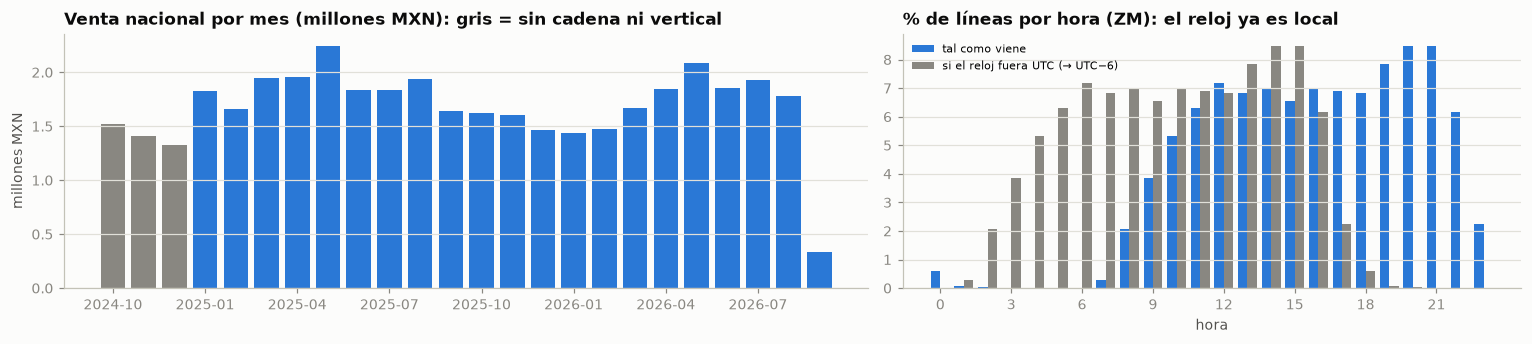

In [4]:
primera = nac.groupby("Product_Brand").mes.min()
peso = nac.groupby("Product_Brand").beverage_sales.sum() / nac.beverage_sales.sum()
tardias = primera[(primera > primera.min()) & (peso.reindex(primera.index) >= 0.01)]
cobertura = nac.groupby("mes").agg(líneas=("order_code", "size"), venta=("beverage_sales", "sum"),
                                   **{"% sin cadena": ("store_group_name", lambda s: s.isna().mean() * 100),
                                      "% sin vertical": ("vertical", lambda s: s.isna().mean() * 100)})
for b_ in tardias.index:
    cobertura[f"venta {b_} (entra {tardias[b_]}, {peso[b_]:.0%} del país)"] = nac[nac.Product_Brand.eq(b_)].groupby("mes").beverage_sales.sum()
display(cobertura.fillna(0).round(1))
completo = cobertura.index[(cobertura["% sin cadena"] < 1) & (cobertura["% sin vertical"] < 1)]
COBERTURA = (f"En {', '.join(cobertura.index[cobertura['% sin cadena'] >= 99])} el archivo no trae cadena ni vertical en todo el país"
             + (f" y {', '.join(tardias.index)} ({', '.join(f'{peso[b]:.0%}' for b in tardias.index)} de la venta nacional) aparece hasta "
                f"{', '.join(sorted(set(tardias)))}" if len(tardias) else "")
             + f": cambio de cobertura, no de demanda (en la ZM el nodo genérico 'Bebidas Hidratantes' también se concentra ahí). "
               f"La ventana empieza en {mes_txt(ini)} (primer mes completo: {completo.min()}) y termina en {mes_txt(cierre)}, igual que las ventas del cliente.")
print(COBERTURA)

hora = pd.DataFrame({"tal como viene": zmx.fecha.dt.hour.value_counts(normalize=True),
                     "si el reloj fuera UTC (→ UTC−6)": (zmx.fecha - pd.Timedelta(hours=6)).dt.hour.value_counts(normalize=True)}
                    ).reindex(range(24)).fillna(0) * 100
madrugada = hora.loc[1:6].sum()
RELOJ = (f"Líneas entre 1 y 6 h: {madrugada.iloc[0]:.1f}% tal como viene vs {madrugada.iloc[1]:.1f}% si fuera UTC: "
         f"el reloj ya es hora local (no se convierte).")
print(RELOJ)
print(f"Rango del archivo en la ZM: {zmx.fecha.min()} → {zmx.fecha.max()} | ventana usada: {ini.date()} → {cierre.date()}")
F_PDV = C.PROC / f"pdv_{C.CLIENTE}_{C.SLUG}.parquet"          # ventas del cliente (00), solo para confirmar el cierre
if F_PDV.exists():
    v = pd.read_parquet(F_PDV, columns=["primera_venta", "ultima_venta"])
    print(f"Ventas {C.CLIENTE}: {v.primera_venta.min():%Y-%m} → {v.ultima_venta.max():%Y-%m} | mismo cierre: "
          f"{v.ultima_venta.max().strftime('%Y-%m') == cierre.strftime('%Y-%m')}")

fig, ax = plt.subplots(1, 2, figsize=(14, 3.2), gridspec_kw={"width_ratios": [1.3, 1]})
cz = cobertura.venta / 1e6
ax[0].bar(range(len(cz)), cz, color=[AZUL if m in completo else eda.MUTED for m in cz.index])
ax[0].set_xticks(range(0, len(cz), 3), cz.index[::3])
ax[0].set(title="Venta nacional por mes (millones MXN): gris = sin cadena ni vertical", ylabel="millones MXN")
ax[1].bar(hora.index - 0.2, hora.iloc[:, 0], width=0.4, color=AZUL, label=hora.columns[0])
ax[1].bar(hora.index + 0.2, hora.iloc[:, 1], width=0.4, color=eda.MUTED, label=hora.columns[1])
ax[1].set(title="% de líneas por hora (ZM): el reloj ya es local", xlabel="hora", xticks=range(0, 24, 3))
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 1.4 Embudo: qué queda en cada filtro y por qué sale lo demás (con mapa)

,paso,líneas,pedidos,venta MXN,store_id,% de las líneas del paso anterior
0,0 · archivo nacional,864704,684677,"40,257,085.460",28079,NaN
1,1 · tienda dentro de la ZM Mérida (polígono),29785,24415,"1,476,729.580",581,3.440
2,2 · sueros y derivados (regla 'sueros primero'),29677,24331,"1,469,757.550",579,99.640
3,3 · ventana ene-2025 → ago-2026,26876,21947,"1,351,184.690",555,90.560


,líneas,venta_MXN,tiendas,ejemplos
motivo,,,,
entra,26876,"1,351,184.690",555,"Powerade, BRAND_7010, BRAND_4866"
fuera de la ventana,2801,"118,572.860",307,"Powerade, BRAND_7010, Flashlyte"
no es suero ni derivado (Vitamin Water: agua funcional),108,"6,972.030",39,"Glacéau Vitamin Water, Vitamin Water"
sin coordenadas,4,190.000,3,No disponible


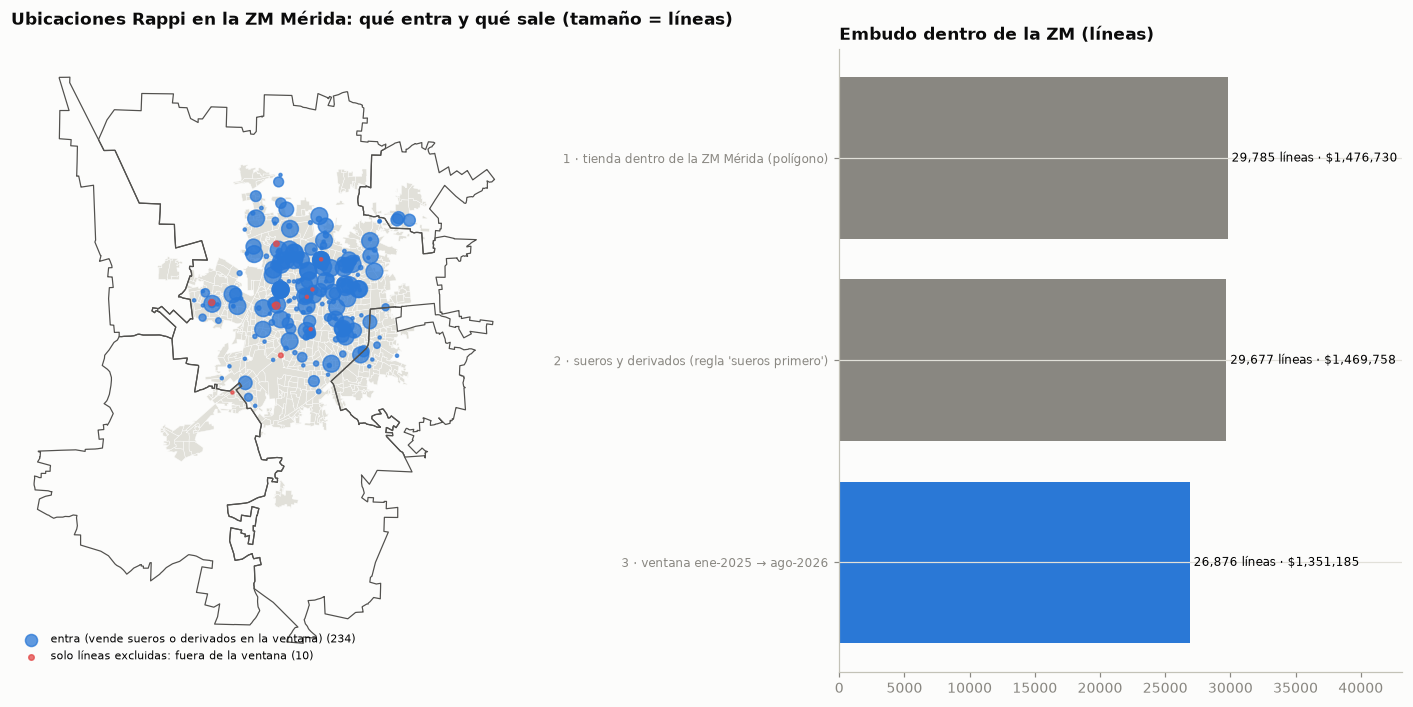

In [5]:
cand["motivo"] = np.select(
    [~con_xy, ~cand.en_zm, cand.subcategoria.isna(), ~cand.fecha.between(ini, fin, inclusive="left")],
    ["sin coordenadas", "fuera de la ZM", cand.regla, "fuera de la ventana"], "entra")
u = cand[cand.motivo.eq("entra")].copy()
u["subcategoria"] = u.subcategoria.astype(str)


def paso(nombre, df):
    return {"paso": nombre, "líneas": len(df), "pedidos": df.order_code.nunique(), "venta MXN": df.beverage_sales.sum(),
            "store_id": df.store_id.nunique()}


embudo = pd.DataFrame([
    paso("0 · archivo nacional", nac),
    paso(f"1 · tienda dentro de la {C.ZM_NOMBRE} (polígono)", zmx),
    paso("2 · sueros y derivados (regla 'sueros primero')", zmx[zmx.subcategoria.notna()]),
    paso(f"3 · ventana {mes_txt(ini)} → {mes_txt(cierre)}", u)])
embudo["% de las líneas del paso anterior"] = (embudo.líneas / embudo.líneas.shift() * 100).round(2)
display(embudo)
excluidas = (cand[cand.etiqueta_ciudad | cand.en_zm].groupby("motivo")
             .agg(líneas=("order_code", "size"), venta_MXN=("beverage_sales", "sum"), tiendas=("store_id", "nunique"),
                  ejemplos=("Product_Brand", lambda s: ", ".join(s.value_counts().index[:3].astype(str)))).sort_values("líneas", ascending=False))
display(excluidas)

# mapa de QA: cada ubicación Rappi con su estado (entra si alguna línea entra)
loc = (cand[con_xy].assign(entra=cand.motivo.eq("entra"))
       .groupby(["store_lat", "store_lng"]).agg(entra=("entra", "any"), motivo=("motivo", lambda s: s.value_counts().index[0]),
                                                líneas=("order_code", "size")).reset_index())
loc["estado"] = np.where(loc.entra, "entra (vende sueros o derivados en la ventana)", "solo líneas excluidas: " + loc.motivo)
gl = gpd.GeoDataFrame(loc, geometry=gpd.points_from_xy(loc.store_lng, loc.store_lat), crs=4326).to_crs(mun.crs)
fig, ax = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1.25, 1]})
agebs.plot(ax=ax[0], color=eda.GRID, edgecolor=eda.FONDO, lw=0.3)
zm.boundary.plot(ax=ax[0], color=eda.TINTA_2, lw=0.8)
colores = dict(zip(sorted(gl.estado.unique(), key=lambda e: not e.startswith("entra")), [AZUL, ROJO, AMBAR, MORADO, NARANJA, ROSA, VERDE2]))
for e, g in gl.groupby("estado"):
    g.plot(ax=ax[0], color=colores[e], markersize=np.clip(g.líneas, 4, 120), alpha=0.75, label=f"{e} ({len(g)})")
ax[0].set_axis_off()
ax[0].legend(loc="lower left", fontsize=7)
ax[0].set_title(f"Ubicaciones Rappi en la {C.ZM_NOMBRE}: qué entra y qué sale (tamaño = líneas)")
e2 = embudo.iloc[1:]
ax[1].barh(e2.paso, e2.líneas, color=[eda.MUTED] * (len(e2) - 1) + [AZUL])
for k, (n_, v_) in enumerate(zip(e2.líneas, e2["venta MXN"])):
    ax[1].text(n_, k, f" {n_:,} líneas · ${v_:,.0f}", va="center", fontsize=8)
ax[1].invert_yaxis()
ax[1].set_title("Embudo dentro de la ZM (líneas)")
ax[1].tick_params(axis="y", labelsize=8)
ax[1].set_xlim(0, e2.líneas.max() * 1.45)
plt.tight_layout(); plt.show()

**Lectura:** si todas las líneas dentro de la ZM traen la etiqueta de la ciudad y ninguna con la etiqueta cae fuera (salvo
las que no tienen coordenadas), la etiqueta y el polígono coinciden y el universo es el correcto. De producto solo sale lo
que no es suero ni derivado (Vitamin Water, refrescos); las marcas sin subcategoría **entran** porque pueden ser sueros.

## 2. Grano, llaves, duplicados y tiendas físicas

* **Llave del pedido:** cada `order_code` debe tener una sola tienda, una sola fecha-hora y un solo usuario.
* **Duplicados:** las líneas idénticas pueden ser un error de carga o dos productos distintos que se ven iguales. Los
  productos Coca-Cola traen su código de barras: ahí una línea repetida sí sería error, y su tasa sirve de **línea base**.
  Los competidores vienen anonimizados a nivel marca: dos sabores de la misma marca al mismo precio en un pedido quedan
  idénticos. Si la tasa de los competidores es mucho mayor que la base, el exceso es anonimización, no error.
* **Tienda física:** Rappi da un `store_id` por "tienda virtual" (…_Express, …_Super, …_Pharma, …_Licores): se agrupan las
  coordenadas a ≤ 25 m en una tienda física.

In [6]:
g_ped = u.groupby("order_code").agg(tiendas=("store_id", "nunique"), horas=("fecha", "nunique"), usuarios=("user_code", "nunique"))
LLAVE = (f"{len(g_ped):,} pedidos · con más de una tienda: {(g_ped.tiendas > 1).sum()} · más de una fecha-hora: {(g_ped.horas > 1).sum()} "
         f"· más de un usuario: {(g_ped.usuarios > 1).sum()}")
print("Llave del pedido:", LLAVE)
print(f"Negativos: importe {(u.beverage_sales < 0).sum()} · unidades {(u.beverage_units < 0).sum()} | ceros: importe {(u.beverage_sales == 0).sum()} "
      f"· unidades {(u.beverage_units == 0).sum()}")
COLS_ORIG = [c for c in R.COLUMNAS if c in u.columns]
u["duplicada"] = u.duplicated(COLS_ORIG, keep=False)
dups = u.groupby("Product_Maker_Standard").agg(líneas=("duplicada", "size"), en_líneas_idénticas=("duplicada", "sum"))
dups["%"] = dups.en_líneas_idénticas / dups.líneas * 100
t_dup = pd.crosstab(u.Product_Maker_Standard, u.duplicada)
DUPLICADOS = (f"Líneas idénticas: Coca-Cola {dups.loc['COCA-COLA', '%']:.1f}% (línea base, tienen código de barras) vs competidores "
              f"{dups.loc['COMPETITOR', '%']:.1f}% (anonimizados); V de Cramér = {eda.cramer_v(t_dup):.2f}, χ² p = "
              f"{stats.chi2_contingency(t_dup)[1]:.0e}. Se conservan: el exceso de los competidores es anonimización.")
display(dups)
print(DUPLICADOS)

xy = u[["store_lat", "store_lng"]].drop_duplicates().reset_index(drop=True)
xy["tienda_fisica"] = R.tiendas_fisicas(xy.store_lat, xy.store_lng, 25)
u = u.merge(xy, on=["store_lat", "store_lng"], how="left")
por_tienda = u.groupby("tienda_fisica").agg(store_ids=("store_id", "nunique"), coordenadas=("store_lat", "nunique"))
multi = u.groupby("store_id").tienda_fisica.nunique()
TIENDAS = (f"{u.store_id.nunique()} store_id y {len(xy)} coordenadas → {u.tienda_fisica.nunique()} tiendas físicas "
           f"(mediana {por_tienda.store_ids.median():.0f} store_id por tienda, máx. {por_tienda.store_ids.max()}); "
           f"{(multi > 1).sum()} store_id aparecen en más de una tienda física (se mudaron o cambiaron de coordenada).")
print(TIENDAS)
ej = u[u.tienda_fisica.eq(por_tienda.store_ids.idxmax())].groupby(["store_id", "store_name", "vertical"], dropna=False).size().rename("líneas")
display(ej.to_frame().head(15))

Llave del pedido: 21,947 pedidos · con más de una tienda: 0 · más de una fecha-hora: 0 · más de un usuario: 0
Negativos: importe 0 · unidades 0 | ceros: importe 0 · unidades 0


,líneas,en_líneas_idénticas,%
Product_Maker_Standard,,,
COCA-COLA,13114,124,0.946
COMPETITOR,13762,2667,19.379


Líneas idénticas: Coca-Cola 0.9% (línea base, tienen código de barras) vs competidores 19.4% (anonimizados); V de Cramér = 0.30, χ² p = 0e+00. Se conservan: el exceso de los competidores es anonimización.
555 store_id y 234 coordenadas → 221 tiendas físicas (mediana 2 store_id por tienda, máx. 28); 0 store_id aparecen en más de una tienda física (se mudaron o cambiaron de coordenada).


,,,líneas
store_id,store_name,vertical,
1923720814,"Turbo, El Rosario",TURBO,3744
1923720876,"Turbo, El Rosario",TURBO,111
1923720878,"Turbo, El Rosario",TURBO,28
1923720879,"Turbo, El Rosario",TURBO,24
1923720883,"Turbo, El Rosario",TURBO,23
1923720884,"Turbo, El Rosario",TURBO,37
1930044341,"Turbo, El Rosario",TURBO,62
1930097088,"Turbo Farma, El Rosario",TURBO,19
1930108871,"Turbo Farma, El Rosario",TURBO,12


## 3. Faltantes y su mecanismo

Antes de imputar hay que saber **por qué** falta cada dato. Si falta solo en un tipo de fila (por diseño de la
exportación), no es azar (MNAR/MAR) y no se imputa: se analiza donde existe.

In [7]:
nulos = u[COLS_ORIG].isna().mean().mul(100).round(1)
display(nulos[nulos > 0].to_frame("% líneas sin dato"))
t_usr = pd.crosstab(u.Product_Maker_Standard, u.user_code.isna().rename("sin usuario"))
t_prod = pd.crosstab(u.Product_Maker_Standard, u.Product_name.isna().rename("sin nombre de producto"))
display(t_usr)
edad = u.age.where(u.age >= 15)                              # 0-14 años no son compradores válidos: se tratan como faltantes
FALTANTES = (f"Usuario y producto faltan exactamente en los competidores (V de Cramér usuario = {eda.cramer_v(t_usr):.2f}, "
             f"producto = {eda.cramer_v(t_prod):.2f}): anonimización por diseño. Edad: {u.age.isna().mean():.0%} sin dato y "
             f"{(u.age < 15).mean():.1%} con edad < 15 (inválida); género 'O' = {(u.gender == 'O').mean():.0%}.")
print(FALTANTES)

,% líneas sin dato
State,100.000
Product_Code,51.200
Product_name,51.200
user_code,51.200
age,32.000


sin usuario,False,True
Product_Maker_Standard,,
COCA-COLA,13114,0
COMPETITOR,0,13762


Usuario y producto faltan exactamente en los competidores (V de Cramér usuario = 1.00, producto = 1.00): anonimización por diseño. Edad: 32% sin dato y 0.0% con edad < 15 (inválida); género 'O' = 17%.


## 4. Univariado, colas y concentración

Tres niveles: **línea** (importe, unidades, precio unitario), **pedido** (importe y unidades de sueros e hidratación por
pedido) y **tienda física** (venta por mes de vida en la ventana, como `cajas_mes_vida` en el 00: venta / meses desde su
primer mes con venta hasta el cierre, para no premiar a las que entraron tarde ni castigar a las que salieron).
La "unidad" de Rappi es el artículo vendido: una caja de 12 o 24 botellas cuenta 1 (empaque múltiple, sobre todo en Costco).

,n,media,mediana,mediana_IC95,MAD_n,p99,max,asimetria,gini,hill_alpha,cuota_top20%,lectura
variable,,,,,,,,,,,,
beverage_sales,26876,50.275,35.900,"[35.60, 35.90]",14.826,216.750,"1,837.320",11.208,0.339,1.586,43.861,cola muy pesada: usar mediana/MAD y log1p
beverage_units,26876,1.654,1.000,"[1.00, 1.00]",0.000,6.000,30.000,6.705,0.305,2.362,42.186,asimetrica: usar log1p
precio_unitario,26876,32.649,31.000,"[30.90, 31.50]",8.896,49.000,"1,129.100",18.027,0.198,1.166,32.153,cola muy pesada: usar mediana/MAD y log1p
importe,21947,61.566,40.500,"[40.00, 41.00]",21.201,309.080,"1,837.320",8.118,0.387,2.333,47.150,asimetrica: usar log1p
unidades,21947,2.025,1.000,"[1.00, 1.00]",0.000,10.000,40.000,5.683,0.374,2.504,47.909,asimetrica: usar log1p
líneas,21947,1.225,1.000,"[1.00, 1.00]",0.000,4.000,15.000,5.225,0.160,3.516,34.670,asimetrica: usar log1p
venta_mes,221,337.756,78.225,"[55.57, 99.84]",96.703,"5,023.352","13,585.501",8.390,0.790,1.030,81.173,cola muy pesada: usar mediana/MAD y log1p
venta_sueros_mes,221,103.563,17.800,"[13.00, 24.50]",26.390,"2,142.769","3,157.675",6.430,0.814,1.070,79.480,cola muy pesada: usar mediana/MAD y log1p
pedidos_mes,221,5.513,1.400,"[1.00, 1.80]",1.652,66.510,252.100,9.340,0.774,1.235,79.582,cola muy pesada: usar mediana/MAD y log1p


,familia,parametros,logL,AIC,KS_D,ΔAIC,nivel
0,lognorm,"[0.6149, 0.0, 48.2569]","-105,547.358","211,098.716",0.124,0.000,pedido (importe)
1,gamma,"[2.205, 0.0, 27.9205]","-109,180.367","218,364.734",0.149,"7,266.019",pedido (importe)
2,weibull_min,"[1.2646, 0.0, 67.3117]","-111,109.481","222,222.963",0.189,"11,124.247",pedido (importe)
3,expon,"[0.0, 61.5658]","-112,370.979","224,743.958",0.274,"13,645.243",pedido (importe)


,familia,parametros,logL,AIC,KS_D,ΔAIC,nivel
0,lognorm,"[1.6481, 0.0, 74.7439]","-1,377.414","2,758.829",0.038,0.000,tienda (venta/mes)
1,weibull_min,"[0.5788, 0.0, 172.2978]","-1,402.075","2,808.150",0.094,49.321,tienda (venta/mes)
2,gamma,"[0.4311, 0.0, 783.4997]","-1,431.747","2,867.494",0.146,108.666,tienda (venta/mes)
3,expon,"[0.0, 337.7556]","-1,507.733","3,017.467",0.319,258.638,tienda (venta/mes)


Empaques múltiples (precio por 'unidad' > $150): 160 líneas (0.6%) y 5.8% de la venta, sobre todo en Costco, Soriana. Box-Cox λ del importe por pedido = -0.54.


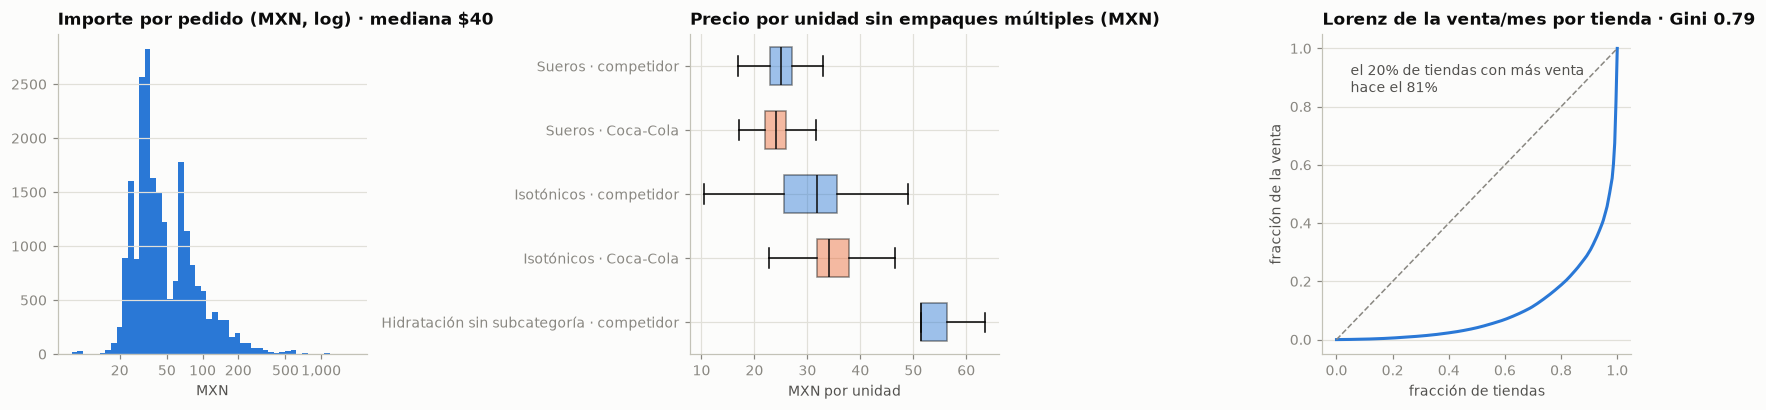

In [8]:
u["precio_unitario"] = u.beverage_sales / u.beverage_units
u["multiempaque"] = u.precio_unitario > 150                  # un suero o isotónico individual cuesta 20-50 MXN
u["mes_n"] = u.fecha.dt.year * 12 + u.fecha.dt.month - 1
u["mes"] = u.fecha.dt.strftime("%Y-%m")
MES_FIN = cierre.year * 12 + cierre.month - 1
cc = u.Product_Maker_Standard.eq("COCA-COLA")
ped = u.assign(cc=cc, suero=u.subcategoria.eq(SUEROS), iso=u.subcategoria.eq(ISOTONICOS)).groupby("order_code").agg(
    tienda=("tienda_fisica", "first"), fecha=("fecha", "first"), usuario=("user_code", "first"), pago=("User_Attribute_1", "first"),
    importe=("beverage_sales", "sum"), unidades=("beverage_units", "sum"), líneas=("store_id", "size"),
    con_coca=("cc", "any"), solo_coca=("cc", "all"), con_suero=("suero", "any"), con_isotonico=("iso", "any"))
ped["con_competidor"] = ~ped.solo_coca


def moda(s):
    s = s.dropna()
    return s.value_counts().index[0] if len(s) else np.nan


tf = u.assign(cc_venta=u.beverage_sales.where(cc, 0), s_venta=u.beverage_sales.where(u.subcategoria.eq(SUEROS), 0),
              s_ped=u.order_code.where(u.subcategoria.eq(SUEROS))).groupby("tienda_fisica").agg(
    nombre=("store_name", moda), cadena=("store_group_name", moda), vertical=("vertical", moda), municipio=("municipio", moda),
    lat=("store_lat", "median"), lon=("store_lng", "median"), store_ids=("store_id", "nunique"),
    venta=("beverage_sales", "sum"), venta_sueros=("s_venta", "sum"), venta_coca=("cc_venta", "sum"), unidades=("beverage_units", "sum"),
    pedidos=("order_code", "nunique"), pedidos_sueros=("s_ped", "nunique"), líneas=("store_id", "size"),
    meses_activos=("mes_n", "nunique"), primer_mes=("mes_n", "min"), ultimo_mes=("mes_n", "max"))
tf["meses_vida"] = MES_FIN - tf.primer_mes + 1
tf["venta_mes"] = tf.venta / tf.meses_vida
tf["venta_sueros_mes"] = tf.venta_sueros / tf.meses_vida
tf["pedidos_mes"] = tf.pedidos / tf.meses_vida
tf["unidades_mes"] = tf.unidades / tf.meses_vida
tf["tasa_actividad"] = tf.meses_activos / tf.meses_vida
tf["recencia_meses"] = MES_FIN - tf.ultimo_mes
tf["% sueros"] = tf.venta_sueros / tf.venta * 100
tf["% Coca-Cola"] = tf.venta_coca / tf.venta * 100
TIPO = {"TURBO": "Turbo (dark store)", "SUPER": "Supermercado", "EXPRESS": "Conveniencia", "PHARMACY": "Farmacia"}
tf["tipo"] = np.where(tf.cadena.eq("Turbo"), TIPO["TURBO"], tf.vertical.map(TIPO).fillna("Otro"))
uni = pd.concat([eda.univariado(u, ["beverage_sales", "beverage_units", "precio_unitario"]),
                 eda.univariado(ped, ["importe", "unidades", "líneas"]),
                 eda.univariado(tf, ["venta_mes", "venta_sueros_mes", "pedidos_mes", "meses_activos", "tasa_actividad"])])
display(uni[["n", "media", "mediana", "mediana_IC95", "MAD_n", "p99", "max", "asimetria", "gini", "hill_alpha", "cuota_top20%", "lectura"]])
aj_ped = eda.ajuste_distribuciones(ped.importe.to_numpy())
aj_tf = eda.ajuste_distribuciones(tf.venta_mes.to_numpy())
display(aj_ped.assign(nivel="pedido (importe)"))
display(aj_tf.assign(nivel="tienda (venta/mes)"))
lam = stats.boxcox(ped.importe.to_numpy())[1]
MULTI = (f"Empaques múltiples (precio por 'unidad' > $150): {u.multiempaque.sum()} líneas ({u.multiempaque.mean():.1%}) y "
         f"{u.beverage_sales[u.multiempaque].sum() / u.beverage_sales.sum():.1%} de la venta, sobre todo en "
         f"{', '.join(u.store_group_name[u.multiempaque].value_counts().index[:2].astype(str))}. Box-Cox λ del importe por pedido = {lam:.2f}.")
print(MULTI)

fx, fy = eda.lorenz(tf.venta_mes.to_numpy())
top20 = 1 - np.interp(0.8, fx, fy)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(np.log10(ped.importe), bins=50, color=AZUL)
ax[0].set_xticks(np.log10([20, 50, 100, 200, 500, 1000]), ["20", "50", "100", "200", "500", "1,000"])
ax[0].set(title=f"Importe por pedido (MXN, log) · mediana ${ped.importe.median():.0f}", xlabel="MXN")
grupos = list(u[~u.multiempaque].groupby(["subcategoria", "Product_Maker_Standard"]))
for k, ((s, m), g) in enumerate(grupos):
    ax[1].boxplot(g.precio_unitario, positions=[k], widths=0.6, orientation="horizontal", showfliers=False, patch_artist=True,
                  boxprops=dict(facecolor=NARANJA if m == "COCA-COLA" else AZUL, alpha=0.45), medianprops=dict(color=eda.TINTA))
ax[1].set_yticks(range(len(grupos)), [f"{s.split(' (')[0]} · {'Coca-Cola' if m == 'COCA-COLA' else 'competidor'}" for (s, m), _ in grupos])
ax[1].set(title="Precio por unidad sin empaques múltiples (MXN)", xlabel="MXN por unidad")
ax[1].grid(axis="x", color=eda.GRID)
ax[2].plot(fx, fy, color=AZUL)
ax[2].plot([0, 1], [0, 1], color=eda.MUTED, lw=1, ls="--")
ax[2].set(title=f"Lorenz de la venta/mes por tienda · Gini {eda.gini(tf.venta_mes):.2f}", xlabel="fracción de tiendas", ylabel="fracción de la venta")
ax[2].text(0.05, 0.85, f"el 20% de tiendas con más venta\nhace el {top20:.0%}", color=eda.TINTA_2)
plt.tight_layout(); plt.show()

## 5. Tiempo y calendario

Serie diaria de toda la ZM (los días sin líneas se rellenan con 0 para detectar huecos de captura). Pruebas: crecimiento
año contra año en los **mismos meses** (ene–ago 2025 vs ene–ago 2026) con IC por **bootstrap de semanas** (los días de una
semana no son independientes), total y por fabricante; estacionalidad por mes calendario (Kruskal-Wallis, ε²) y temporada
de calor (abr–jun) contra la fresca (nov–feb) con δ de Cliff; día de la semana y quincena (días 15–17 y 30–2).

Días de la ventana: 608 | días sin ninguna línea en la ZM: 0 (huecos de captura)


,prueba,efecto,detalle
0,Crecimiento ene–ago 2026 vs 2025 · venta total,+3.6%,"IC95 bootstrap de semanas [-6.3%, +15.1%]"
1,Crecimiento ene–ago 2026 vs 2025 · Coca-Cola,+8.4%,"IC95 bootstrap de semanas [-4.7%, +23.3%]"
2,Crecimiento ene–ago 2026 vs 2025 · competidores,-0.3%,"IC95 bootstrap de semanas [-11.8%, +12.2%]"
3,Crecimiento ene–ago 2026 vs 2025 · pedidos,-9.6%,"IC95 bootstrap de semanas [-17.4%, -1.0%]"
4,Estacionalidad por mes (Kruskal-Wallis),ε² = 0.234,"IC95 [0.193, 0.306] · q = 2.3e-26"
5,"Calor (abr–jun) vs fresca (nov–feb), venta diaria",δ = +0.59,"mediana $2,621 vs $1,728 · p = 4.4e-22"
6,Día de la semana (Kruskal-Wallis),ε² = 0.093,"IC95 [0.060, 0.159] · fin de semana vs entre semana δ = +0.32"
7,Quincena (días 15–17 y 30–2) vs resto,δ = +0.08,p = 0.17


,venta,pedidos,unidades,tiendas,usuarios,ticket,% sueros,% Coca-Cola
mes,,,,,,,,
2025-01,"49,202.600",869,"1,576.000",91,334,56.600,43.700,38.800
2025-02,"49,142.400",943,"1,722.000",86,373,52.100,31.300,45.500
2025-03,"66,449.000",1126,"2,286.000",88,403,59.000,31.600,42.500
2025-04,"62,262.800",1013,"2,026.000",94,374,61.500,29.800,41.700
2025-05,"89,383.000",1551,"3,069.000",99,579,57.600,26.400,44.500
2025-06,"74,172.000",1333,"2,680.000",93,481,55.600,32.000,44.400
2025-07,"76,317.900",1281,"2,626.000",90,471,59.600,27.900,43.400
2025-08,"74,784.300",1278,"2,549.000",95,546,58.500,23.500,56.600
2025-09,"64,614.000",1092,"2,299.000",88,422,59.200,22.600,55.300


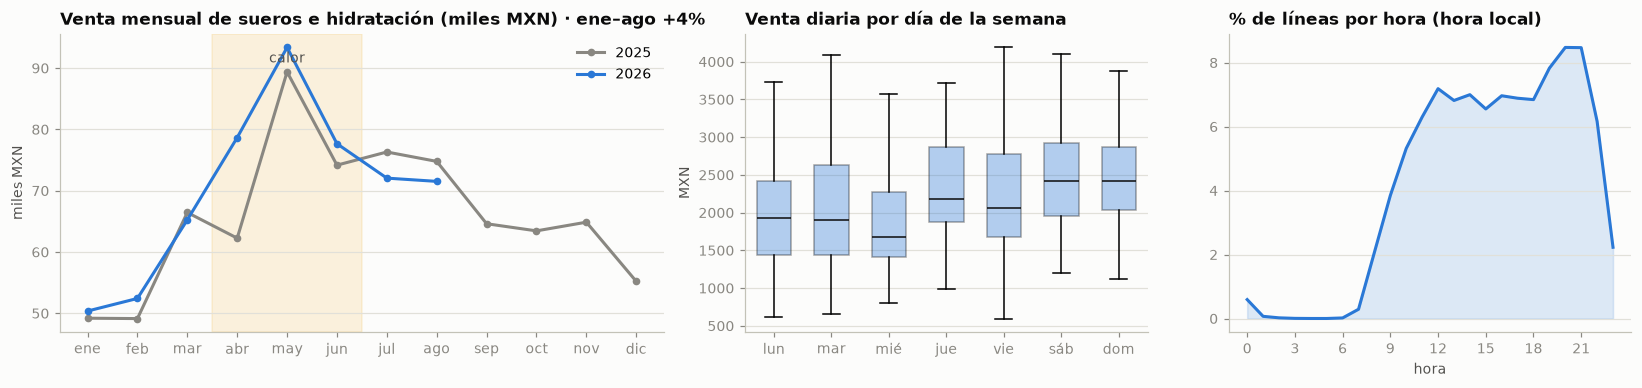

In [9]:
dia = (u.groupby(u.fecha.dt.normalize()).agg(venta=("beverage_sales", "sum"), pedidos=("order_code", "nunique"),
                                             venta_cc=("beverage_sales", lambda s: s[cc.loc[s.index]].sum()))
       .reindex(pd.date_range(ini, cierre, freq="D"), fill_value=0))
dia["mes_cal"] = dia.index.month
dia["dow"] = dia.index.dayofweek
dia["semana"] = (dia.index - ini).days // 7
dia["venta_comp"] = dia.venta - dia.venta_cc
print(f"Días de la ventana: {len(dia)} | días sin ninguna línea en la ZM: {(dia.pedidos == 0).sum()} (huecos de captura)")
mensual = u.groupby("mes").agg(venta=("beverage_sales", "sum"), pedidos=("order_code", "nunique"), unidades=("beverage_units", "sum"),
                               tiendas=("tienda_fisica", "nunique"), usuarios=("user_code", "nunique"))
mensual["ticket"] = mensual.venta / mensual.pedidos
mensual["% sueros"] = u.assign(v=u.beverage_sales.where(u.subcategoria.eq(SUEROS), 0)).groupby("mes").v.sum() / mensual.venta * 100
mensual["% Coca-Cola"] = u.assign(v=u.beverage_sales.where(cc, 0)).groupby("mes").v.sum() / mensual.venta * 100

a1, a2 = dia[(dia.index >= "2025-01-01") & (dia.index < "2025-09-01")], dia[(dia.index >= "2026-01-01") & (dia.index < "2026-09-01")]


def yoy(col):
    sa, sb = a1.groupby("semana").indices, a2.groupby("semana").indices
    xa, xb = a1[col].to_numpy(), a2[col].to_numpy()
    bs = [xb[np.concatenate([sb[k] for k in rng.choice(list(sb), len(sb))])].mean() /
          xa[np.concatenate([sa[k] for k in rng.choice(list(sa), len(sa))])].mean() - 1 for _ in range(2000)]
    return xb.sum() / xa.sum() - 1, *np.quantile(bs, [0.025, 0.975])


crec = {c: yoy(c) for c in ["venta", "venta_cc", "venta_comp", "pedidos"]}
calor, fresca = dia[dia.mes_cal.isin([4, 5, 6])].venta, dia[dia.mes_cal.isin([11, 12, 1, 2])].venta
d_calor = eda.cliff_delta(calor, fresca)
quin = dia.index.day.isin([15, 16, 17, 30, 31, 1, 2])
d_quin = eda.cliff_delta(dia.venta[quin], dia.venta[~quin])
finde = dia.dow >= 5
d_finde = eda.cliff_delta(dia.venta[finde], dia.venta[~finde])
cal = eda.efecto_categorico(dia.assign(mes_cal=dia.mes_cal.astype(str), dow=dia.dow.astype(str)), ["mes_cal", "dow"], "venta").set_index("variable")
calendario = pd.DataFrame([
    *[(f"Crecimiento ene–ago 2026 vs 2025 · {n_}", f"{crec[c][0]:+.1%}", f"IC95 bootstrap de semanas [{crec[c][1]:+.1%}, {crec[c][2]:+.1%}]")
      for c, n_ in [("venta", "venta total"), ("venta_cc", "Coca-Cola"), ("venta_comp", "competidores"), ("pedidos", "pedidos")]],
    ("Estacionalidad por mes (Kruskal-Wallis)", f"ε² = {cal.loc['mes_cal', 'epsilon2']:.3f}", f"IC95 {cal.loc['mes_cal', 'IC95']} · q = {cal.loc['mes_cal', 'q_BH']:.1e}"),
    ("Calor (abr–jun) vs fresca (nov–feb), venta diaria", f"δ = {d_calor:+.2f}",
     f"mediana ${calor.median():,.0f} vs ${fresca.median():,.0f} · p = {stats.mannwhitneyu(calor, fresca).pvalue:.1e}"),
    ("Día de la semana (Kruskal-Wallis)", f"ε² = {cal.loc['dow', 'epsilon2']:.3f}", f"IC95 {cal.loc['dow', 'IC95']} · fin de semana vs entre semana δ = {d_finde:+.2f}"),
    ("Quincena (días 15–17 y 30–2) vs resto", f"δ = {d_quin:+.2f}", f"p = {stats.mannwhitneyu(dia.venta[quin], dia.venta[~quin]).pvalue:.2f}"),
], columns=["prueba", "efecto", "detalle"])
with pd.option_context("display.max_colwidth", None):
    display(calendario)
display(mensual.round(1))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6), gridspec_kw={"width_ratios": [1.5, 1, 1]})
for anio, col in [("2025", eda.MUTED), ("2026", AZUL)]:
    s = mensual.venta[mensual.index.str.startswith(anio)]
    ax[0].plot([int(m[5:]) for m in s.index], s.values / 1000, "o-", color=col, label=anio, ms=4)
ax[0].set_xticks(range(1, 13), ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"])
ax[0].axvspan(3.5, 6.5, color=AMBAR, alpha=0.12)
ax[0].text(5, ax[0].get_ylim()[1] * 0.97, "calor", ha="center", va="top", color=eda.TINTA_2)
ax[0].set(title=f"Venta mensual de sueros e hidratación (miles MXN) · ene–ago {crec['venta'][0]:+.0%}", ylabel="miles MXN")
ax[0].legend()
ax[1].boxplot([dia.venta[dia.dow == k] for k in range(7)], widths=0.6, showfliers=False, patch_artist=True,
              boxprops=dict(facecolor=AZUL, alpha=0.35), medianprops=dict(color=eda.TINTA))
ax[1].set_xticks(range(1, 8), ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"])
ax[1].set(title="Venta diaria por día de la semana", ylabel="MXN")
ax[2].plot(hora.index, hora.iloc[:, 0], color=AZUL)
ax[2].fill_between(hora.index, hora.iloc[:, 0], color=AZUL, alpha=0.15)
ax[2].set(title="% de líneas por hora (hora local)", xlabel="hora", xticks=range(0, 24, 3))
plt.tight_layout(); plt.show()

## 6. Fabricante, marca y precio

`Product_Maker_Standard` separa **Coca-Cola** (el sistema de Bepensa: Powerade, Flashlyte) de los **competidores**.
Participación por valor, unidades y pedidos; su tendencia mensual (τ de Kendall contra el tiempo) y el precio por unidad
de Coca-Cola contra competidores dentro de cada subcategoría, sin empaques múltiples (Mann-Whitney, δ de Cliff, q de BH).
No se estima elasticidad: los competidores no traen SKU y no hay marcas de promoción (el precio cambia con el empaque).

In [10]:
fab = u.groupby("Product_Maker_Standard").agg(venta=("beverage_sales", "sum"), unidades=("beverage_units", "sum"),
                                              líneas=("store_id", "size"), pedidos=("order_code", "nunique"))
fab_pct = (fab / fab.sum() * 100).add_prefix("% ")
sub_fab = pd.crosstab(u.subcategoria, u.Product_Maker_Standard, values=u.beverage_sales, aggfunc="sum", margins=True, normalize="index") * 100
sub_tot = u.groupby("subcategoria").beverage_sales.sum() / u.beverage_sales.sum() * 100
tipo_fab = pd.crosstab(u.tienda_fisica.map(tf.tipo), u.Product_Maker_Standard, values=u.beverage_sales, aggfunc="sum", normalize="index") * 100
tau_cc = stats.kendalltau(np.arange(len(mensual)), mensual["% Coca-Cola"])
display(pd.concat([fab, fab_pct], axis=1).round(1))
display(sub_fab.round(1).join(sub_tot.rename("% de la venta total")))
display(tipo_fab.round(1).rename_axis("tipo de tienda"))
marcas_top = (u.groupby(["Product_Brand", "Product_Maker_Standard", "subcategoria"])
              .agg(venta=("beverage_sales", "sum"), líneas=("store_id", "size"), precio_mediano=("precio_unitario", "median"),
                   multiempaque_pct=("multiempaque", "mean"), tiendas=("tienda_fisica", "nunique")).reset_index().sort_values("venta", ascending=False))
marcas_top["% venta"] = marcas_top.venta / marcas_top.venta.sum() * 100
marcas_top["multiempaque_pct"] *= 100
display(marcas_top.head(12).round(1))
precio = []
for s, g in u[~u.multiempaque].groupby("subcategoria"):
    a, b = g.precio_unitario[g.Product_Maker_Standard.eq("COCA-COLA")], g.precio_unitario[g.Product_Maker_Standard.eq("COMPETITOR")]
    if len(a) >= 20 and len(b) >= 20:
        precio.append({"subcategoria": s, "n Coca-Cola": len(a), "n competidor": len(b), "mediana Coca-Cola": a.median(),
                       "mediana competidor": b.median(), "δ Cliff (CC vs comp)": eda.cliff_delta(a, b), "p": stats.mannwhitneyu(a, b).pvalue})
precio = pd.DataFrame(precio)
precio["q_BH"] = stats.false_discovery_control(precio.p, method="bh")
display(precio.round(3))
MARCAS = (f"Sueros = {sub_tot.get(SUEROS, 0):.0f}% de la venta, isotónicos {sub_tot.get(ISOTONICOS, 0):.0f}%, sin subcategoría "
          f"{sub_tot.get(R.SIN_SUB, 0):.1f}%. Coca-Cola hace {fab_pct.loc['COCA-COLA', '% venta']:.0f}% del valor (sueros "
          f"{sub_fab.loc[SUEROS, 'COCA-COLA']:.0f}%, isotónicos {sub_fab.loc[ISOTONICOS, 'COCA-COLA']:.0f}%); tendencia de su "
          f"participación mensual τ = {tau_cc[0]:+.2f} (p = {tau_cc[1]:.2f}).")
print(MARCAS)

,venta,unidades,líneas,pedidos,% venta,% unidades,% líneas,% pedidos
Product_Maker_Standard,,,,,,,,
COCA-COLA,"641,899.000","20,406.000",13114,11757,47.500,45.900,48.800,51.800
COMPETITOR,"709,285.700","24,047.000",13762,10935,52.500,54.100,51.200,48.200


,COCA-COLA,COMPETITOR,% de la venta total
subcategoria,,,
Hidratación sin subcategoría,0.000,100.000,0.896
Isotónicos (derivados),59.300,40.700,68.576
Sueros (hidratantes),22.300,77.700,30.527
All,47.500,52.500,NaN


Product_Maker_Standard,COCA-COLA,COMPETITOR
tipo de tienda,,
Conveniencia,48.700,51.300
Farmacia,32.300,67.700
Otro,0.000,100.000
Supermercado,39.200,60.800
Turbo (dark store),61.400,38.600


,Product_Brand,Product_Maker_Standard,subcategoria,venta,líneas,precio_mediano,multiempaque_pct,tiendas,% venta
17,Powerade,COCA-COLA,Isotónicos (derivados),"549,856.200",10873,34.000,0.000,171,40.700
13,BRAND_7010,COMPETITOR,Isotónicos (derivados),"374,287.300",7330,31.900,1.100,151,27.700
12,BRAND_4866,COMPETITOR,Sueros (hidratantes),"191,345.900",4173,25.000,0.200,144,14.200
16,Flashlyte,COCA-COLA,Sueros (hidratantes),"92,042.800",2241,24.000,0.000,105,6.800
4,BRAND_26138,COMPETITOR,Sueros (hidratantes),"56,093.900",1336,25.900,0.100,93,4.200
7,BRAND_28347,COMPETITOR,Sueros (hidratantes),"28,278.500",47,582.100,100.000,2,2.100
8,BRAND_28393,COMPETITOR,Sueros (hidratantes),"23,714.600",326,44.600,3.100,37,1.800
10,BRAND_29867,COMPETITOR,Hidratación sin subcategoría,"11,160.700",10,"1,129.100",100.000,1,0.800
5,BRAND_26331,COMPETITOR,Sueros (hidratantes),"8,749.300",158,8.700,0.000,28,0.600
2,BRAND_23355,COMPETITOR,Sueros (hidratantes),"6,204.500",130,24.900,0.000,20,0.500


,subcategoria,n Coca-Cola,n competidor,mediana Coca-Cola,mediana competidor,δ Cliff (CC vs comp),p,q_BH
0,Isotónicos (derivados),10873,7297,34.000,31.900,0.252,0.000,0.000
1,Sueros (hidratantes),2241,6298,23.980,25.000,-0.174,0.000,0.000


Sueros = 31% de la venta, isotónicos 69%, sin subcategoría 0.9%. Coca-Cola hace 48% del valor (sueros 22%, isotónicos 59%); tendencia de su participación mensual τ = +0.19 (p = 0.26).


## 7. Canasta y clientes

* **Canasta:** líneas y unidades por pedido; co-compra de Coca-Cola con competidor y de suero con isotónico en el mismo
  pedido: soporte, **lift** = P(A y B) / (P(A)·P(B)) y prueba exacta de Fisher (lift < 1 = se sustituyen; > 1 = se complementan).
* **Clientes:** solo las líneas Coca-Cola traen usuario, así que la recompra se mide en compradores de Coca-Cola:
  frecuencia, índice de dispersión (varianza / media; > 1 = sobredispersión frente a Poisson), % que recompra, recencia
  al cierre e independencia frecuencia–ticket (supuesto Gamma-Gamma).
* **Pago:** mezcla de medios de pago por tienda. El % de Apple Pay y de efectivo es una señal digital de NSE (como el %
  iOS de AltScore) que el 06 contrasta con el NSE de INEGI alrededor de cada tienda.

In [11]:
def co_compra(a, b):
    t = pd.crosstab(a, b).reindex(index=[False, True], columns=[False, True], fill_value=0)
    ab = (a & b).mean()
    return {"soporte A": a.mean(), "soporte B": b.mean(), "soporte A y B": ab, "lift": ab / (a.mean() * b.mean()),
            "p Fisher": stats.fisher_exact(t.to_numpy())[1]}


canasta = pd.DataFrame({"Coca-Cola × competidor": co_compra(ped.con_coca, ped.con_competidor),
                        "suero × isotónico": co_compra(ped.con_suero, ped.con_isotonico)}).T
display(canasta.round(4))
print(f"Líneas por pedido: {ped.líneas.value_counts(normalize=True).mul(100).round(1).head(4).to_dict()} (%)")
cli = (ped.dropna(subset=["usuario"]).groupby("usuario")
       .agg(pedidos=("importe", "size"), gasto=("importe", "sum"), ticket=("importe", "mean"), ultima=("fecha", "max")))
disp = cli.pedidos.var() / cli.pedidos.mean()
chi_disp = ((cli.pedidos - cli.pedidos.mean()) ** 2).sum() / cli.pedidos.mean()
rep = cli[cli.pedidos >= 2]
gg = stats.spearmanr(rep.pedidos, rep.ticket)
CLIENTES = (f"{len(cli):,} compradores de Coca-Cola: {(cli.pedidos >= 2).mean():.0%} recompra; pedidos por comprador mediana "
            f"{cli.pedidos.median():.0f}, p90 {cli.pedidos.quantile(0.9):.0f}; dispersión var/media = {disp:.1f} "
            f"(Poisson p = {stats.chi2.sf(chi_disp, len(cli) - 1):.0e}); recencia mediana {(fin - cli.ultima).dt.days.median():.0f} días; "
            f"frecuencia × ticket ρ = {gg[0]:+.2f} (Gamma-Gamma {'razonable' if abs(gg[0]) < 0.1 else 'dudoso'}).")
print(CLIENTES)
pago = ped.pago.value_counts(normalize=True).mul(100).round(1)
display(pago.to_frame("% pedidos"))
pago_tienda = pd.crosstab(ped.tienda, ped.pago, normalize="index") * 100
tf["% pago efectivo"] = pago_tienda.get("cash")
tf["% pago Apple Pay"] = pago_tienda.get("apple_pay")
print(f"Edad (≥ 15): mediana {edad.median():.0f} años (IQR {edad.quantile(0.25):.0f}–{edad.quantile(0.75):.0f}) · género: "
      + ", ".join(f"{k} {v:.0%}" for k, v in u.gender.value_counts(normalize=True).items()))

,soporte A,soporte B,soporte A y B,lift,p Fisher
Coca-Cola × competidor,0.536,0.498,0.034,0.127,0.000
suero × isotónico,0.302,0.717,0.019,0.090,0.000


Líneas por pedido: {1: 83.6, 2: 12.5, 3: 2.7, 4: 0.7} (%)
5,171 compradores de Coca-Cola: 30% recompra; pedidos por comprador mediana 1, p90 4; dispersión var/media = 10.7 (Poisson p = 0e+00); recencia mediana 281 días; frecuencia × ticket ρ = +0.10 (Gamma-Gamma razonable).


,% pedidos
pago,
cc,58.500
cash,19.600
rappi_pay_gateway,8.500
paypal,6.400
apple_pay,4.500
yuno_mercado_pago,2.500


Edad (≥ 15): mediana 33 años (IQR 28–39) · género: M 44%, F 39%, O 17%


## 8. Espacial: tiendas físicas en la ZM (mapa)

Tamaño = venta/mes de sueros e hidratación; color = tipo de tienda. Los **Turbo** son dark stores de Rappi: no atienden a
quien pasa, despachan a domicilio a toda su zona de reparto (varios km), así que su venta no es demanda de sus 300 m. Se
mide la concentración (Gini, top 10) y si las tiendas están agrupadas: razón de Clark-Evans R = distancia media al vecino
más cercano observada / esperada si estuvieran al azar en el área urbana (R < 1 = agrupadas; z de la prueba).

,tiendas,venta_mes,mediana_venta_mes,venta_sueros_mes,% venta,% sueros en su venta
tipo,,,,,,
Supermercado,48,"27,052.300",162.800,"9,030.600",36.200,33.400
Turbo (dark store),2,"24,265.500","12,132.800","5,438.300",32.500,22.400
Conveniencia,93,"13,072.300",87.000,"3,248.200",17.500,24.800
Farmacia,68,"10,049.400",38.900,"5,092.300",13.500,50.700
Otro,10,204.500,7.400,78.000,0.300,38.200


221 tiendas físicas; Gini venta/mes = 0.79; las 10 más grandes hacen 58% (Turbo: 33% con 2 tiendas). Vecino más cercano: mediana 341 m; Clark-Evans R = 0.80 (z = -5.8): agrupadas en el área urbana.


,tiendas,venta_mes
municipio,,
Conkal,3,421.000
Kanasín,8,"1,309.000"
Mérida,210,"72,913.000"


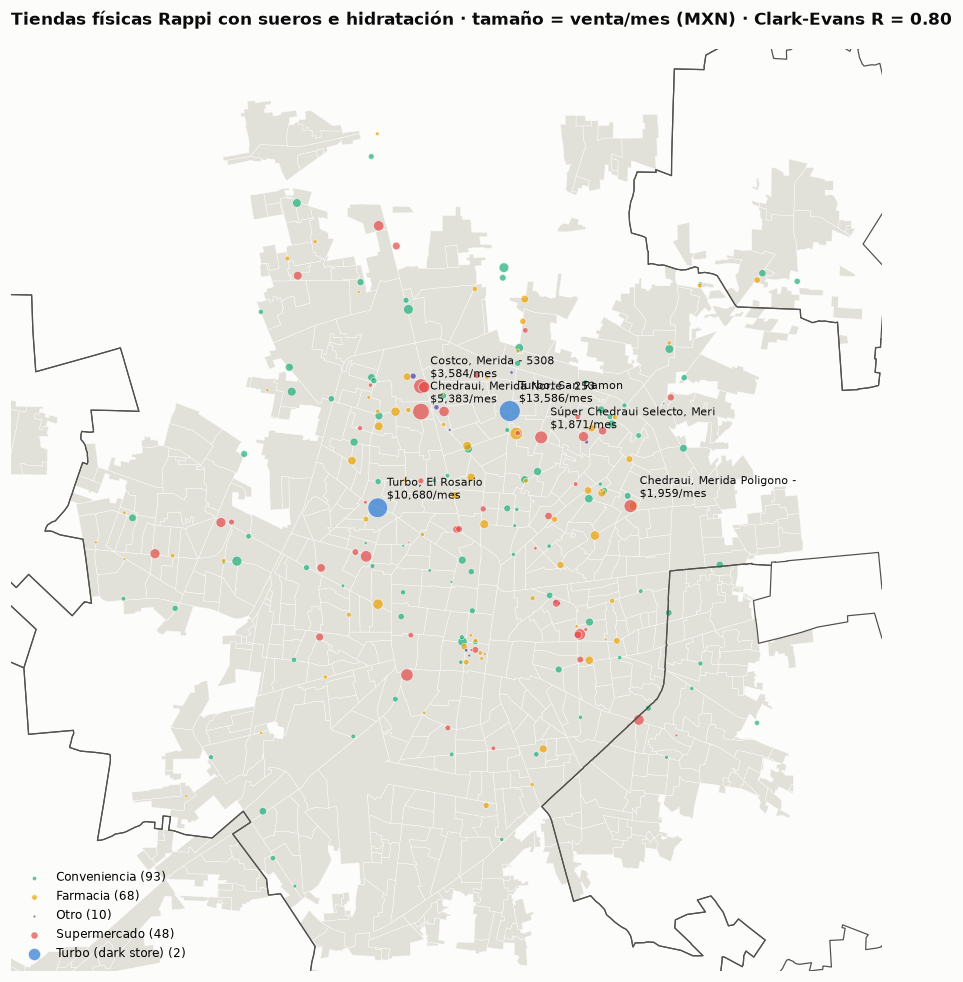

In [12]:
tf_g = gpd.GeoDataFrame(tf, geometry=gpd.points_from_xy(tf.lon, tf.lat), crs=4326).to_crs(mun.crs)
area_urbana = agebs.to_crs(mun.crs).area.sum()
XY_TF = np.radians(tf[["lat", "lon"]].to_numpy())
dd, _ = BallTree(XY_TF, metric="haversine").query(XY_TF, k=2)
nn = dd[:, 1] * R.RADIO_TIERRA_M
lam_ = len(tf) / area_urbana
esperada = 0.5 / np.sqrt(lam_)
ce = nn.mean() / esperada
z_ce = (nn.mean() - esperada) / (0.26136 / np.sqrt(len(tf) * lam_))
tipo_res = tf.groupby("tipo").agg(tiendas=("venta", "size"), venta_mes=("venta_mes", "sum"), mediana_venta_mes=("venta_mes", "median"),
                                  venta_sueros_mes=("venta_sueros_mes", "sum"))
tipo_res["% venta"] = tipo_res.venta_mes / tipo_res.venta_mes.sum() * 100
tipo_res["% sueros en su venta"] = tipo_res.venta_sueros_mes / tipo_res.venta_mes * 100
display(tipo_res.sort_values("venta_mes", ascending=False).round(1))
top10 = tf.venta_mes.nlargest(10).sum() / tf.venta_mes.sum()
turbo_pct = tipo_res["% venta"].get(TIPO["TURBO"], 0)
ESPACIAL = (f"{len(tf)} tiendas físicas; Gini venta/mes = {eda.gini(tf.venta_mes):.2f}; las 10 más grandes hacen {top10:.0%} "
            f"(Turbo: {turbo_pct:.0f}% con {int(tipo_res.tiendas.get(TIPO['TURBO'], 0))} tiendas). Vecino más cercano: mediana "
            f"{np.median(nn):,.0f} m; Clark-Evans R = {ce:.2f} (z = {z_ce:.1f}): {'agrupadas' if ce < 1 else 'dispersas'} en el área urbana.")
print(ESPACIAL)
display(tf.groupby("municipio").agg(tiendas=("venta", "size"), venta_mes=("venta_mes", "sum")).round(0))

fig, ax = plt.subplots(figsize=(10, 9))
agebs.to_crs(mun.crs).plot(ax=ax, color=eda.GRID, edgecolor=eda.FONDO, lw=0.3)
zm.boundary.plot(ax=ax, color=eda.TINTA_2, lw=0.8)
col_tipo = dict(zip(tipo_res.sort_values("venta_mes", ascending=False).index, [ROJO, AZUL, VERDE, AMBAR, MORADO, NARANJA, ROSA, VERDE2]))
for t_, g in tf_g.groupby("tipo"):
    g.plot(ax=ax, color=col_tipo[t_], markersize=np.sqrt(g.venta_mes) * 1.6, alpha=0.7, edgecolor=eda.FONDO, lw=0.5, label=f"{t_} ({len(g)})")
for _, r in tf_g.nlargest(6, "venta_mes").iterrows():
    ax.annotate(f"{r.nombre[:28]}\n${r.venta_mes:,.0f}/mes", (r.geometry.x, r.geometry.y), fontsize=7, xytext=(6, 6),
                textcoords="offset points", color=eda.TINTA)
ax.set_xlim(tf_g.total_bounds[[0, 2]] + np.array([-2500, 2500]))
ax.set_ylim(tf_g.total_bounds[[1, 3]] + np.array([-2500, 2500]))
ax.set_axis_off()
ax.legend(loc="lower left", fontsize=8, markerscale=0.6)
ax.set_title(f"Tiendas físicas Rappi con sueros e hidratación · tamaño = venta/mes (MXN) · Clark-Evans R = {ce:.2f}")
plt.tight_layout(); plt.show()

## 9. Reglas de selección: qué pasa a las letras (notebook 06)

Se fijan **antes** de cruzar con Bepensa (el 06 hace el cruce y sus pruebas):

| Regla | Criterio | Si no se cumple |
|---|---|---|
| R1 universo | ZM por polígono, sueros y derivados ("sueros primero"), ventana ene-2025 → ago-2026 (sección 1) | no entra |
| R2 tienda activa | ≥ `C.RAPPI_MIN_PEDIDOS` pedidos de sueros o derivados en la ventana (uno cada ~2 meses): la demanda se repite | esporádica: se reporta; en el 06 entra al Rappi del buffer y su exclusión se prueba en la sensibilidad |
| R3 activa en sueros | ≥ `C.RAPPI_MIN_PEDIDOS` pedidos **con suero** | se reporta |
| R4 tipo | los Turbo (dark stores) se **marcan**: su venta es de toda su zona de reparto, no de sus 300 m | entra marcada (el 06 mide la sensibilidad sin ellos) |
| R5 señales | por tienda física: venta total y de sueros, pedidos y unidades por mes de vida, meses activos, % Coca-Cola, % pago en efectivo y Apple Pay | — |

In [13]:
tf["activa"] = tf.pedidos >= C.RAPPI_MIN_PEDIDOS
tf["activa_sueros"] = tf.pedidos_sueros >= C.RAPPI_MIN_PEDIDOS
tf["turbo"] = tf.tipo.eq(TIPO["TURBO"])
sel = tf.groupby(["activa", "activa_sueros"]).agg(tiendas=("venta", "size"), venta_mes=("venta_mes", "sum"), pedidos=("pedidos", "sum"))
sel["% venta"] = sel.venta_mes / sel.venta_mes.sum() * 100
display(sel.round(1))
SELECCION = (f"R2: {int(tf.activa.sum())} de {len(tf)} tiendas físicas activas (≥ {C.RAPPI_MIN_PEDIDOS} pedidos) hacen "
             f"{tf.venta_mes[tf.activa].sum() / tf.venta_mes.sum():.1%} de la venta; R3: {int(tf.activa_sueros.sum())} activas en sueros; "
             f"R4: {int(tf.turbo.sum())} Turbo marcadas ({tf.venta_mes[tf.turbo].sum() / tf.venta_mes.sum():.0%} de la venta).")
print(SELECCION)

tiendas  venta_mes  pedidos  % venta
activa activa_sueros                                      
False  False              115  4,442.500      458    6.000
True   False               34  4,662.900     1051    6.200
       True                72 65,538.600    20438   87.800

R2: 106 de 221 tiendas físicas activas (≥ 12 pedidos) hacen 94.0% de la venta; R3: 72 activas en sueros; R4: 2 Turbo marcadas (33% de la venta).


## 10. QA de las decisiones: ¿cambia el resultado si la regla fuera otra?

Cada decisión de limpieza se prueba contra su alternativa: solo la subcategoría de Rappi (sin reglas 2-4), quitar
duplicados, empezar en oct-2024 (con los meses de cobertura incompleta), reloj UTC, radio de tienda física (10 / 50 m) y
umbral de tienda activa (1 / 6 / 24 pedidos).

In [14]:
solo_rappi = u.regla.str.startswith("1")
sin_dup = ~u.duplicated(COLS_ORIG)
cambia_mes = (u.fecha - pd.Timedelta(hours=6)).dt.strftime("%Y-%m") != u.mes
desde_oct = cand[cand.en_zm & cand.subcategoria.notna() & cand.fecha.between(pd.Timestamp("2024-10-01"), fin, inclusive="left")]
qa = [("Solo la subcategoría de Rappi (sin marca, nombre ni categoría)", f"{solo_rappi.mean():.1%} de las líneas",
       f"{u.beverage_sales[solo_rappi].sum() / u.beverage_sales.sum():.1%} de la venta; tiendas {u.tienda_fisica[solo_rappi].nunique()} de {u.tienda_fisica.nunique()}"),
      ("Quitar líneas idénticas", f"{sin_dup.mean():.1%} de las líneas", f"{u.beverage_sales[sin_dup].sum() / u.beverage_sales.sum():.1%} de la venta"),
      ("Empezar en oct-2024 (con los 3 meses de cobertura incompleta)", f"{len(desde_oct) / len(u) - 1:+.1%} líneas",
       f"{desde_oct.beverage_sales.sum() / u.beverage_sales.sum() - 1:+.1%} de venta, sin cadena, vertical ni BRAND_4866 en esos meses: sesga tendencias"),
      ("Reloj UTC (restar 6 h)", f"{cambia_mes.mean():.2%} de las líneas cambiaría de mes", f"{u.beverage_sales[cambia_mes].sum() / u.beverage_sales.sum():.2%} de la venta")]
for r_ in (10, 50):
    xy_ = xy.assign(t=R.tiendas_fisicas(xy.store_lat, xy.store_lng, r_))
    qa.append((f"Radio de tienda física {r_} m (base 25 m)", f"{xy_.t.nunique()} tiendas", f"vs {xy.tienda_fisica.nunique()} con 25 m"))
for m_ in (1, 6, 24):
    act = tf.pedidos >= m_
    qa.append((f"Tienda activa con ≥ {m_} pedidos (base {C.RAPPI_MIN_PEDIDOS})", f"{int(act.sum())} tiendas activas",
               f"{tf.venta_mes[act].sum() / tf.venta_mes.sum():.1%} de la venta"))
qa = pd.DataFrame(qa, columns=["alternativa", "efecto", "detalle"])
with pd.option_context("display.max_colwidth", None):
    display(qa)

,alternativa,efecto,detalle
0,"Solo la subcategoría de Rappi (sin marca, nombre ni categoría)",99.9% de las líneas,99.0% de la venta; tiendas 221 de 221
1,Quitar líneas idénticas,94.0% de las líneas,95.2% de la venta
2,Empezar en oct-2024 (con los 3 meses de cobertura incompleta),+9.4% líneas,"+7.7% de venta, sin cadena, vertical ni BRAND_4866 en esos meses: sesga tendencias"
3,Reloj UTC (restar 6 h),0.07% de las líneas cambiaría de mes,0.06% de la venta
4,Radio de tienda física 10 m (base 25 m),227 tiendas,vs 221 con 25 m
5,Radio de tienda física 50 m (base 25 m),218 tiendas,vs 221 con 25 m
6,Tienda activa con ≥ 1 pedidos (base 12),221 tiendas activas,100.0% de la venta
7,Tienda activa con ≥ 6 pedidos (base 12),138 tiendas activas,97.0% de la venta
8,Tienda activa con ≥ 24 pedidos (base 12),89 tiendas activas,91.6% de la venta


## 11. Salidas y hallazgos

In [15]:
lineas = u[["fecha", "mes", "order_code", "store_id", "store_name", "store_group_name", "vertical", "tienda_fisica", "store_lat", "store_lng",
            "cve_mun", "municipio", "subcategoria", "regla", "Product_Category_2", "Product_Category_3", "Product_Brand", "Product_Maker_Standard",
            "Product_name", "beverage_sales", "beverage_units", "precio_unitario", "multiempaque", "user_code", "age", "gender",
            "User_Attribute_1", "duplicada"]]
lineas.to_parquet(C.PROC / f"rappi_hidratacion_lineas_{C.SLUG}.parquet", index=False)
tiendas_out = tf.reset_index()
tiendas_out.to_parquet(C.PROC / f"rappi_hidratacion_tiendas_{C.SLUG}.parquet", index=False)
mensual.reset_index().to_parquet(C.PROC / f"rappi_hidratacion_mensual_{C.SLUG}.parquet", index=False)

hallazgos00c = pd.DataFrame([
    ("Universo", f"{len(u):,} líneas, {u.order_code.nunique():,} pedidos y ${u.beverage_sales.sum():,.0f} MXN de sueros y derivados en la "
                 f"{C.ZM_NOMBRE} ({mes_txt(ini)} → {mes_txt(cierre)}), de {len(nac):,} líneas nacionales.",
     "Es la única data de Rappi que se usa (ciudad activa, sueros e hidratación, ventana con cobertura completa)."),
    ("Ciudad", f"Etiquetas {sorted(etiquetas.city.unique())} = {C.RAPPI_CIUDAD}; dentro de la ZM con otra etiqueta: "
               f"{int((~cand.etiqueta_ciudad & cand.en_zm).sum())}; con la etiqueta y sin coordenadas: {int((cand.etiqueta_ciudad & ~con_xy).sum())}.",
     "La etiqueta y el polígono coinciden: el universo es el correcto."),
    ("Producto", "Regla 'sueros primero' en la ZM (ventana): " + "; ".join(f"{k} {int(v):,} líneas" for k, v in por_regla[f"líneas {C.ZM_NOMBRE} (ventana)"].items() if v)
                 + f". Pureza de marca {marcas.pureza.min():.2f}.",
     "Entran sueros y derivados aunque vengan fuera de su categoría; sale solo lo que no es suero (Vitamin Water, refrescos)."),
    ("Cobertura y ventana", COBERTURA, "Crecimientos y tendencias solo en meses comparables (ene–ago)."),
    ("Reloj", RELOJ, "Los meses se asignan con la hora tal como viene."),
    ("Llave y duplicados", f"{LLAVE}. {DUPLICADOS}", "Grano = línea de pedido; no se borran líneas."),
    ("Tiendas físicas", TIENDAS, "El 06 cruza por tienda física (coordenada), no por store_id."),
    ("Faltantes", FALTANTES, "Clientes y producto solo se analizan en Coca-Cola; nada se imputa."),
    ("Colas y empaques", f"Importe por pedido: mediana ${ped.importe.median():.0f} (mejor ajuste {aj_ped.familia.iloc[0]}); venta/mes por tienda "
                         f"mediana ${tf.venta_mes.median():,.0f}, Gini {eda.gini(tf.venta_mes):.2f}, el 20% de las tiendas hace {top20:.0%}. {MULTI}",
     "Venta muy concentrada: medianas y rangos, no medias; precio sin empaques múltiples."),
    ("Calendario", "; ".join(f"{r.prueba}: {r.efecto} ({r.detalle.split(' ·')[0]})" for r in calendario.itertuples()),
     "La hidratación sigue al calor (abr–jun); el Rappi del 06 usa toda la ventana para no depender de la temporada."),
    ("Marcas", MARCAS, "Coca-Cola (sistema Bepensa) domina isotónicos; en sueros compite con marcas anonimizadas."),
    ("Canasta", f"Coca-Cola × competidor lift = {canasta.loc['Coca-Cola × competidor', 'lift']:.2f}; suero × isotónico lift = "
                f"{canasta.loc['suero × isotónico', 'lift']:.2f} (Fisher p = {canasta.loc['suero × isotónico', 'p Fisher']:.0e}).",
     "Lift < 1: el comprador elige una marca o subcategoría por pedido (sustitutos)."),
    ("Clientes", CLIENTES, "RFM solo con Coca-Cola (competidores sin usuario)."),
    ("Espacial", ESPACIAL, "Los Turbo concentran la venta: su zona de reparto es de km, no de 300 m (el 06 mide la sensibilidad sin ellos)."),
    ("Selección", SELECCION, "Pasan al 06 todas las tiendas físicas con sus señales (R5); el 06 prueba usar solo las activas (R2) y quitar los Turbo (R4)."),
], columns=["tema", "hallazgo", "implicación"])
with pd.option_context("display.max_colwidth", None):
    display(hallazgos00c)

import excel_kin as X


def para_excel(df):
    """Sí / No en vez de VERDADERO / FALSO."""
    return df.map(lambda v: ("Sí" if v else "No") if isinstance(v, (bool, np.bool_)) else v)


wb = X.libro()
X.hoja_tabla(wb, "Hallazgos", hallazgos00c.rename(columns=str.capitalize), titulo="Hallazgos del EDA de Rappi (sueros e hidratación)", ajustar=True,
             anchos={"Tema": 20, "Hallazgo": 105, "Implicación": 60})
X.hoja_tabla(wb, "Embudo", embudo.round(2), titulo="Qué queda en cada filtro",
             nota="Universo = tiendas en la ZM (polígono) · sueros y derivados ('sueros primero') · ventana con cobertura completa.",
             formatos={"líneas": "#,##0", "pedidos": "#,##0", "venta MXN": "#,##0", "store_id": "#,##0"}, anchos={"paso": 52})
X.hoja_tabla(wb, "Reglas producto", por_regla.round(0).rename_axis("regla"), indice=True, titulo="Regla que clasifica cada línea (ZM y país)",
             formatos={c: "#,##0" for c in por_regla.columns}, anchos={"regla": 58})
X.hoja_tabla(wb, "Excluidas", excluidas.round(0).rename_axis("motivo"), indice=True, titulo="Líneas de la ciudad que no entran y por qué",
             formatos={"venta_MXN": "#,##0"}, anchos={"motivo": 58, "ejemplos": 50})
X.hoja_tabla(wb, "Reasignación", reasignacion.round(2), titulo="Líneas clasificadas por marca, nombre o categoría (reglas 2-4) y Vitamin Water",
             anchos={"regla": 46, "subcategoria": 26})
X.hoja_tabla(wb, "Cobertura", cobertura.fillna(0).round(1).reset_index(), titulo="Cobertura del archivo por mes (todo el país)",
             nota="Meses sin cadena ni vertical y marcas grandes que aparecen tarde = cambio de cobertura, no de demanda.")
X.hoja_tabla(wb, "Tiendas", para_excel(tiendas_out.round(2)), titulo="Tiendas físicas Rappi con sueros e hidratación (señales para el 06)",
             nota=f"activa = ≥ {C.RAPPI_MIN_PEDIDOS} pedidos en la ventana; venta_mes = venta / meses de vida en la ventana (MXN).",
             formatos={"venta": "#,##0", "venta_mes": "#,##0", "venta_sueros_mes": "#,##0", "pedidos_mes": "0.0", "unidades_mes": "0.0",
                       "% sueros": "0.0", "% Coca-Cola": "0.0", "lat": "0.000000", "lon": "0.000000"}, barras=["venta_mes"], anchos={"nombre": 40})
X.hoja_tabla(wb, "Mensual", mensual.round(1).reset_index(), titulo="Serie mensual de la ZM", formatos={"venta": "#,##0", "ticket": "0.0"})
X.hoja_tabla(wb, "Calendario", calendario, titulo="Crecimiento y calendario", anchos={"prueba": 48, "detalle": 70})
X.hoja_tabla(wb, "Marcas", marcas_top.round(2), titulo="Marcas por venta (competidores anonimizados)", formatos={"venta": "#,##0"})
X.hoja_tabla(wb, "Precio", precio.round(4), titulo="Precio por unidad sin empaques múltiples: Coca-Cola vs competidor")
X.hoja_tabla(wb, "Canasta", canasta.round(4).rename_axis("par"), indice=True, titulo="Co-compra en el mismo pedido (lift y Fisher)")
X.hoja_tabla(wb, "Univariado", uni.round(3).reset_index(), titulo="Univariado por nivel (línea, pedido, tienda)", anchos={"variable": 22, "lectura": 40})
X.hoja_tabla(wb, "QA decisiones", qa, titulo="Sensibilidad de cada decisión de limpieza", anchos={"alternativa": 58, "efecto": 32, "detalle": 60})
X.hoja_tabla(wb, "Datos", FUENTES_RAPPI, titulo="Archivo de Rappi usado", anchos={"ruta": 40, "sha256": 66})
X.portada(wb, "EDA de Rappi · sueros e hidratación", f"{C.ZM_NOMBRE} · sueros y derivados · {mes_txt(ini)} → {mes_txt(cierre)}",
          [("Universo", f"{len(u):,} líneas, {u.order_code.nunique():,} pedidos, {len(tf)} tiendas físicas."),
           ("Filtros", "Tienda dentro de la ZM (polígono); sueros y derivados con la regla 'sueros primero'; ventana con cobertura completa."),
           ("Uso", f"Letra 2 (notebook 06): el Rappi de cada PDV es la venta media de las tiendas Rappi a ≤ {C.RADIO_PDV_M} m; entra por rango con peso 1."),
           ("Elaboró", "Kin Analytics · notebooks/_src/00c_rappi_eda.py")],
          [("Hallazgos", "Qué se encontró y qué implica."), ("Embudo", "Qué queda en cada filtro."), ("Reglas producto", "Qué regla clasifica cada línea."),
           ("Excluidas", "Qué sale y por qué."), ("Reasignación", "Marca, nombre y categoría."), ("Cobertura", "Cobertura del archivo por mes."),
           ("Tiendas", "Tiendas físicas y sus señales."), ("Mensual", "Serie mensual."), ("Calendario", "Crecimiento, estacionalidad, día y quincena."),
           ("Marcas", "Marcas y fabricante."), ("Precio", "Precio por unidad."), ("Canasta", "Co-compra."), ("Univariado", "Colas y concentración."),
           ("QA decisiones", "Sensibilidad."), ("Datos", "Procedencia.")])
out = C.OUT / f"00c_rappi_hidratacion_eda_{C.SLUG}.xlsx"
wb.save(out)
print("Guardado:", out.name, "|", f"rappi_hidratacion_tiendas_{C.SLUG}.parquet ({len(tf)} tiendas, {int(tf.activa.sum())} activas)",
      "|", f"rappi_hidratacion_lineas_{C.SLUG}.parquet ({len(u):,} líneas)")

,tema,hallazgo,implicación
0,Universo,"26,876 líneas, 21,947 pedidos y $1,351,185 MXN de sueros y derivados en la ZM Mérida (ene-2025 → ago-2026), de 864,704 líneas nacionales.","Es la única data de Rappi que se usa (ciudad activa, sueros e hidratación, ventana con cobertura completa)."
1,Ciudad,"Etiquetas ['Merida', 'Mérida'] = ['MERIDA']; dentro de la ZM con otra etiqueta: 0; con la etiqueta y sin coordenadas: 4.",La etiqueta y el polígono coinciden: el universo es el correcto.
2,Producto,"Regla 'sueros primero' en la ZM (ventana): 1 · subcategoría de Rappi 26,838 líneas; 2 · subcategoría de su marca en el país 21 líneas; 4 · categoría de hidratación sin subcategoría 17 líneas; no es suero ni derivado (Vitamin Water: agua funcional) 16 líneas. Pureza de marca 1.00.","Entran sueros y derivados aunque vengan fuera de su categoría; sale solo lo que no es suero (Vitamin Water, refrescos)."
3,Cobertura y ventana,"En 2024-10, 2024-11, 2024-12 el archivo no trae cadena ni vertical en todo el país y BRAND_28347, BRAND_4866 (1%, 20% de la venta nacional) aparece hasta 2025-01: cambio de cobertura, no de demanda (en la ZM el nodo genérico 'Bebidas Hidratantes' también se concentra ahí). La ventana empieza en ene-2025 (primer mes completo: 2025-01) y termina en ago-2026, igual que las ventas del cliente.",Crecimientos y tendencias solo en meses comparables (ene–ago).
4,Reloj,Líneas entre 1 y 6 h: 0.1% tal como viene vs 25.0% si fuera UTC: el reloj ya es hora local (no se convierte).,Los meses se asignan con la hora tal como viene.
5,Llave y duplicados,"21,947 pedidos · con más de una tienda: 0 · más de una fecha-hora: 0 · más de un usuario: 0. Líneas idénticas: Coca-Cola 0.9% (línea base, tienen código de barras) vs competidores 19.4% (anonimizados); V de Cramér = 0.30, χ² p = 0e+00. Se conservan: el exceso de los competidores es anonimización.",Grano = línea de pedido; no se borran líneas.
6,Tiendas físicas,"555 store_id y 234 coordenadas → 221 tiendas físicas (mediana 2 store_id por tienda, máx. 28); 0 store_id aparecen en más de una tienda física (se mudaron o cambiaron de coordenada).","El 06 cruza por tienda física (coordenada), no por store_id."
7,Faltantes,"Usuario y producto faltan exactamente en los competidores (V de Cramér usuario = 1.00, producto = 1.00): anonimización por diseño. Edad: 32% sin dato y 0.0% con edad < 15 (inválida); género 'O' = 17%.",Clientes y producto solo se analizan en Coca-Cola; nada se imputa.
8,Colas y empaques,"Importe por pedido: mediana $40 (mejor ajuste lognorm); venta/mes por tienda mediana $78, Gini 0.79, el 20% de las tiendas hace 81%. Empaques múltiples (precio por 'unidad' > $150): 160 líneas (0.6%) y 5.8% de la venta, sobre todo en Costco, Soriana. Box-Cox λ del importe por pedido = -0.54.","Venta muy concentrada: medianas y rangos, no medias; precio sin empaques múltiples."
9,Calendario,"Crecimiento ene–ago 2026 vs 2025 · venta total: +3.6% (IC95 bootstrap de semanas [-6.3%, +15.1%]); Crecimiento ene–ago 2026 vs 2025 · Coca-Cola: +8.4% (IC95 bootstrap de semanas [-4.7%, +23.3%]); Crecimiento ene–ago 2026 vs 2025 · competidores: -0.3% (IC95 bootstrap de semanas [-11.8%, +12.2%]); Crecimiento ene–ago 2026 vs 2025 · pedidos: -9.6% (IC95 bootstrap de semanas [-17.4%, -1.0%]); Estacionalidad por mes (Kruskal-Wallis): ε² = 0.234 (IC95 [0.193, 0.306]); Calor (abr–jun) vs fresca (nov–feb), venta diaria: δ = +0.59 (mediana $2,621 vs $1,728); Día de la semana (Kruskal-Wallis): ε² = 0.093 (IC95 [0.060, 0.159]); Quincena (días 15–17 y 30–2) vs resto: δ = +0.08 (p = 0.17)",La hidratación sigue al calor (abr–jun); el Rappi del 06 usa toda la ventana para no depender de la temporada.


Guardado: 00c_rappi_hidratacion_eda_zm_merida.xlsx | rappi_hidratacion_tiendas_zm_merida.parquet (221 tiendas, 106 activas) | rappi_hidratacion_lineas_zm_merida.parquet (26,876 líneas)
